# PROJECT 2 - DỰ ĐOÁN GIÁ VÀ PHÁT HIỆN BẤT THƯỜNG GIÁ XE MÁY CŨ

1. Business Understanding.
2. Environment Setup.
3. Load Data.
4. Data Understanding.
5. Data Preparation.
6. EDA và Motorbike Segmentation.
7. **Bài toán 1 - Dự đoán giá xe**.
   - scikit-learn.
   - Spark ML.
8. **Bài toán 2 - Phát hiện bất thường về giá**.
   - scikit-learn.
   - Spark.
   - So sánh mức đồng thuận và case study.
9. Xuất kết quả.
10. Kết luận chung.

# 1. Business Understanding

Project giải quyết hai bài toán trên dữ liệu xe máy cũ:

- **Price Prediction:** dự đoán mức giá đăng bán hợp lý từ thông tin của xe.
- **Anomaly Detection:** phát hiện các tin có giá quá rẻ hoặc quá đắt so với dự đoán và mặt bằng của phân khúc.

Kết quả có thể hỗ trợ:

- người bán tham khảo giá trước khi đăng tin;
- người kiểm duyệt ưu tiên kiểm tra các tin có cờ đỏ;
- nền tảng giải thích rõ tín hiệu nào khiến một tin bị nghi ngờ.

Mô hình chỉ đưa ra gợi ý. Quyết định cuối cùng vẫn thuộc về người bán và người kiểm duyệt.

# 2. Environment Setup

In [1]:
# Chỉ cài thư viện khi môi trường chưa có.

import importlib.util
import subprocess
import sys

packages = {
    "openpyxl": "openpyxl",
    "pyspark": "pyspark>=3.5,<4.1",
}

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])
if importlib.util.find_spec("pyspark") is not None:
    import pyspark
    print("PySpark version:", pyspark.__version__)
else:
    print("PySpark chưa có trong runtime local.")

PySpark version: 4.0.3


In [2]:
# Import thư viện.

import json
import os
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import shutil

import joblib
import scipy
import sklearn

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SEED = 42
REFERENCE_YEAR = 2025
IN_COLAB = "google.colab" in sys.modules

print("Running in Colab:", IN_COLAB)

Running in Colab: True


# 3. Load Data

In [3]:
# Colab sử dụng /content. Môi trường kiểm tra local sử dụng /mnt/data.

DATA_DIR = Path("/content") if IN_COLAB else Path("/mnt/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "data_motobikes.xlsx"

if not DATA_PATH.exists() and IN_COLAB:
    from google.colab import files

    print("Hãy upload file data_motobikes.xlsx")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = DATA_DIR / uploaded_name

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu: {DATA_PATH}")

print("Data path:", DATA_PATH)

Hãy upload file data_motobikes.xlsx


Saving data_motobikes.xlsx to data_motobikes.xlsx
Data path: /content/data_motobikes.xlsx


In [4]:
# Đọc dữ liệu gốc.

motorbikes_raw = pd.read_excel(DATA_PATH)

print("Shape:", motorbikes_raw.shape)
display(motorbikes_raw.head())

Shape: (7208, 18)


,id,Tiêu đề,Giá,Khoảng giá min,Khoảng giá max,Địa chỉ,Mô tả chi tiết,Thương hiệu,Dòng xe,Năm đăng ký,Số Km đã đi,Tình trạng,Loại xe,Dung tích xe,Xuất xứ,Chính sách bảo hành,Trọng lượng,Href
0,1,"Bán Vespa Sprint 125cc 2024 xanh dương, xe đẹp...",66.000.000 đ,72.53 tr,85.14 tr,"Phường Bến Thành, Quận 1, Tp Hồ Chí Minh",Bán xe #Vespa Sprint 125cc. Mua mới tại #Topco...,Piaggio,Vespa,2024,14000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
1,2,🔥🔥SH 150i Thắng ABS 2019 BSTP Chính Chủ,79.500.000 đ,62.76 tr,73.68 tr,"Phường Tân Định, Quận 1, Tp Hồ Chí Minh","_Bán SH 150i Thắng ABS 2019 Xám Bạc, Úp Team X...",Honda,SH,2019,28000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
2,3,CC Vision Thể Thao 2023 Đen+bộ đèn Demi audi A7,37.000.000 đ,28 tr,32.86 tr,"Phường Cầu Kho, Quận 1, Tp Hồ Chí Minh",Chính chủ bán Vision phiên bản Thể Thao 2023 Đ...,Honda,Vision,2023,12000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
3,4,Vespa Sprint 2019 -125- Đen Đỏ Sport -CHÍNH ...,45.000.000 đ,43.1 tr,50.6 tr,"Phường Bến Nghé, Quận 1, Tp Hồ Chí Minh",XE CÁ NHÂN BÁN - XE DO EM ĐỨNG TÊN CHÍNH C...,Piaggio,Vespa,2019,60000,Đã sử dụng,Tay ga,100 - 175 cc,Đang cập nhật,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...
4,5,Xe tay ga Yamaha Latte 125 – Đăng ký 2021,23.000.000 đ,17.02 tr,19.98 tr,"Phường Tân Định, Quận 1, Tp Hồ Chí Minh",🛵 Thông tin xe:\n\nDòng xe tay ga cao cấp Yama...,Yamaha,Latte,2021,24000,Đã sử dụng,Tay ga,100 - 175 cc,Nhật Bản,Bảo hành hãng,> 50 kg,https://xe.chotot.com/mua-ban-xe-may-quan-1-tp...


`shape` có dạng `(số dòng, số cột)`. Mỗi dòng là một tin đăng xe máy cũ.

# 4. Data Understanding

In [5]:
# Tóm tắt kiểu dữ liệu, missing values và số giá trị khác nhau.

summary_raw = pd.DataFrame({
    "data_type": motorbikes_raw.dtypes.astype(str),
    "missing_values": motorbikes_raw.isna().sum(),
    "missing_percent": motorbikes_raw.isna().mean() * 100,
    "unique_values": motorbikes_raw.nunique(dropna=False),
})

display(summary_raw)

,data_type,missing_values,missing_percent,unique_values
id,int64,0,0.000,7208
Tiêu đề,object,1,0.014,6840
Giá,object,2,0.028,742
Khoảng giá min,object,202,2.802,1305
Khoảng giá max,object,197,2.733,1349
Địa chỉ,object,41,0.569,311
Mô tả chi tiết,object,0,0.000,7183
Thương hiệu,object,3,0.042,38
Dòng xe,object,3,0.042,196
Năm đăng ký,object,0,0.000,79


In [6]:
#Xem phân bố của các cột có giá trị unique thấp

display(motorbikes_raw["Tình trạng"].value_counts())
display(motorbikes_raw["Loại xe"].value_counts())
display(motorbikes_raw["Chính sách bảo hành"].value_counts())
display(motorbikes_raw["Trọng lượng"].value_counts())

,count
Tình trạng,
Đã sử dụng,7207
Mới,1


,count
Loại xe,
Tay ga,3600
Xe số,2189
Tay côn/Moto,1419


,count
Chính sách bảo hành,
Bảo hành hãng,7207


,count
Trọng lượng,
> 50 kg,7207


In [7]:
# Kiểm tra duplicate theo id và đường dẫn tin đăng.

print("Duplicate id:", motorbikes_raw.duplicated(subset="id").sum())
print("Duplicate Href:", motorbikes_raw.duplicated(subset="Href").sum())

Duplicate id: 0
Duplicate Href: 12


In [8]:
# Xem một số giá trị thực tế trước khi làm sạch.

columns_to_check = [
    "Giá",
    "Khoảng giá min",
    "Khoảng giá max",
    "Năm đăng ký",
    "Số Km đã đi",
]

display(motorbikes_raw[columns_to_check].head(10))

,Giá,Khoảng giá min,Khoảng giá max,Năm đăng ký,Số Km đã đi
0,66.000.000 đ,72.53 tr,85.14 tr,2024,14000
1,79.500.000 đ,62.76 tr,73.68 tr,2019,28000
2,37.000.000 đ,28 tr,32.86 tr,2023,12000
3,45.000.000 đ,43.1 tr,50.6 tr,2019,60000
4,23.000.000 đ,17.02 tr,19.98 tr,2021,24000
5,7.500.000 đ,7.73 tr,9.08 tr,2018,25000
6,16.000.000 đ,13.83 tr,16.24 tr,2013,80000
7,7.300.000 đ,10.08 tr,11.83 tr,2003,2
8,7.500.000 đ,6.97 tr,8.19 tr,2015,35000
9,33.000.000 đ,27.45 tr,32.22 tr,2020,20000


### Nhận xét dữ liệu ban đầu

- Dữ liệu gốc có **7,208 dòng và 18 cột**.
- `Giá` thiếu 2 dòng; `Khoảng giá min` thiếu 202 dòng; `Khoảng giá max` thiếu 197 dòng; `Địa chỉ` thiếu 41 dòng.
- Không có duplicate theo `id`, nhưng có **12 đường dẫn `Href` trùng**.
- `Giá` và `Năm đăng ký` đang ở dạng chuỗi nên cần chuyển đổi trước khi phân tích.
- `Tình trạng`, `Chính sách bảo hành` và `Trọng lượng` gần như không thay đổi giữa các dòng, vì vậy không được chọn làm feature.

# 5. Data Preparation

In [9]:
# Đổi chuỗi giá như "66.000.000 đ" thành 66.0 triệu đồng.

def convert_price_to_million(value):
    if pd.isna(value):
        return np.nan

    digits = re.sub(r"\D", "", str(value))
    if digits == "":
        return np.nan

    return float(digits) / 1_000_000

In [10]:
# Đổi khoảng giá như "72.53 tr" thành 72.53 triệu đồng.

def convert_range_to_million(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().replace(",", ".")
    number = re.search(r"\d+(?:\.\d+)?", text)

    return float(number.group()) if number else np.nan

In [11]:
# Chuyển năm đăng ký về dạng số.

def convert_year(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if "trước" in text and "1980" in text:
        return 1979

    year = re.search(r"19\d{2}|20\d{2}", text)
    return float(year.group()) if year else np.nan

In [12]:
# Tách quận/huyện từ cột địa chỉ.

def extract_district(value):
    if pd.isna(value):
        return "Không rõ"

    text = str(value)

    if re.search(r"Thành phố Thủ Đức|TP\.?\s*Thủ Đức", text, re.I):
        return "Thành phố Thủ Đức"

    pattern = (
        r"Quận\s+(?:\d+|Bình Tân|Bình Thạnh|Gò Vấp|Phú Nhuận|Tân Bình|Tân Phú)"
        r"|Huyện\s+(?:Bình Chánh|Cần Giờ|Củ Chi|Hóc Môn|Nhà Bè)"
    )
    result = re.search(pattern, text, re.I)

    return result.group().title() if result else "Không rõ"

In [13]:
# Đổi tên cột để code ngắn và dễ đọc hơn.

motorbikes = motorbikes_raw.rename(columns={
    "Tiêu đề": "title",
    "Giá": "price_raw",
    "Khoảng giá min": "provided_min_raw",
    "Khoảng giá max": "provided_max_raw",
    "Địa chỉ": "address",
    "Mô tả chi tiết": "description",
    "Thương hiệu": "brand",
    "Dòng xe": "model",
    "Năm đăng ký": "year_raw",
    "Số Km đã đi": "km",
    "Tình trạng": "condition",
    "Loại xe": "bike_type",
    "Dung tích xe": "capacity",
    "Xuất xứ": "origin",
    "Chính sách bảo hành": "warranty",
    "Trọng lượng": "weight",
    "Href": "href",
}).copy()

In [14]:
# Tạo các cột số và đặc trưng mới.

motorbikes["price_million"] = motorbikes["price_raw"].map(convert_price_to_million)
motorbikes["provided_min_million"] = motorbikes["provided_min_raw"].map(convert_range_to_million)
motorbikes["provided_max_million"] = motorbikes["provided_max_raw"].map(convert_range_to_million)
motorbikes["year"] = motorbikes["year_raw"].map(convert_year)
motorbikes["age"] = REFERENCE_YEAR - motorbikes["year"]
motorbikes["km"] = pd.to_numeric(motorbikes["km"], errors="coerce")
motorbikes["district"] = motorbikes["address"].map(extract_district)
motorbikes["title_length"] = motorbikes["title"].fillna("").astype(str).str.len()
motorbikes["description_length"] = motorbikes["description"].fillna("").astype(str).str.len()

In [15]:
# Làm sạch các cột phân loại.

categorical_columns = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
]

for column in categorical_columns:
    motorbikes[column] = (
        motorbikes[column]
        .fillna("Không rõ")
        .astype(str)
        .str.strip()
        .replace("", "Không rõ")
    )

In [16]:
# Sửa một số giá trị sai cột trong Dung tích xe.

valid_capacity_values = {
    "Dưới 50 cc",
    "50 - 100 cc",
    "100 - 175 cc",
    "Trên 175 cc",
    "Không biết rõ",
    "Đang cập nhật",
}

invalid_capacity = ~motorbikes["capacity"].isin(valid_capacity_values)
motorbikes.loc[invalid_capacity, "capacity"] = "Không biết rõ"

print("Số giá trị dung tích được sửa:", invalid_capacity.sum())

Số giá trị dung tích được sửa: 1


In [17]:
# Xóa duplicate theo đường dẫn tin đăng.

rows_before = len(motorbikes)
motorbikes = motorbikes.drop_duplicates(subset="href", keep="first").copy()

print("Số dòng trước khi xóa duplicate:", rows_before)
print("Số dòng sau khi xóa duplicate:", len(motorbikes))

Số dòng trước khi xóa duplicate: 7208
Số dòng sau khi xóa duplicate: 7196


In [18]:
# Feature engineering bổ sung cho mô hình triển khai Streamlit.

# Chuẩn hóa title và description thành chuỗi.
motorbikes["title"] = (
    motorbikes["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

motorbikes["description"] = (
    motorbikes["description"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Một số giá trị kilomet rất lớn có thể là placeholder hoặc lỗi nhập.
# Không xóa dòng; thay giá trị đó bằng missing và giữ thêm một cờ.
KM_SUSPICIOUS_LIMIT = 500_000

motorbikes["km_suspicious"] = (
    motorbikes["km"].notna()
    & (
        (motorbikes["km"] < 0)
        | (motorbikes["km"] >= KM_SUSPICIOUS_LIMIT)
    )
).astype(int)

motorbikes["km_clean"] = motorbikes["km"].mask(
    motorbikes["km_suspicious"] == 1
)

# Log kilomet giúp giảm ảnh hưởng của các giá trị kilomet rất lớn.
motorbikes["log_km"] = np.log1p(
    motorbikes["km_clean"].clip(lower=0)
)

# Kilomet trung bình theo tuổi xe.
# age = 0 được thay bằng 1 để tránh chia cho 0.
motorbikes["km_per_year"] = (
    motorbikes["km_clean"]
    / motorbikes["age"].clip(lower=1)
)

# Quan hệ giữa tuổi và giá có thể không tuyến tính.
motorbikes["age_squared"] = motorbikes["age"] ** 2

# Tạo interaction giữa thương hiệu và dòng xe.
motorbikes["brand_model"] = (
    motorbikes["brand"]
    + " | "
    + motorbikes["model"]
)

# Gộp văn bản để tìm các từ khóa kỹ thuật.
listing_text = (
    motorbikes["title"]
    + " "
    + motorbikes["description"]
).str.lower()

# Các từ khóa thường liên quan tới xe nhập khẩu hoặc nguồn gốc đặc biệt.
motorbikes["is_import_keyword"] = listing_text.str.contains(
    (
        r"nhập\s*(?:ý|khẩu|thái)?"
        r"|hqcn"
        r"|hải\s*quan"
        r"|chính\s*ngạch"
        r"|xe\s*thùng"
        r"|đập\s*thùng"
    ),
    regex=True,
    na=False,
).astype(int)

# ABS thường ảnh hưởng đến phiên bản và giá xe.
motorbikes["is_abs_keyword"] = listing_text.str.contains(
    r"(?<!\w)abs(?!\w)",
    regex=True,
    na=False,
).astype(int)

# Một số từ khóa liên quan đến xe hiếm hoặc xe sưu tầm.
motorbikes["is_collectible_keyword"] = listing_text.str.contains(
    (
        r"limited"
        r"|sưu\s*tầm"
        r"|nguyên\s*zin"
        r"|full\s*zin"
        r"|đập\s*thùng"
        r"|(?<!\w)yaz(?!\w)"
        r"|xipo"
        r"|vespa\s*946"
    ),
    regex=True,
    na=False,
).astype(int)

# Cờ dung tích lớn giúp model tách nhóm phân khối lớn.
motorbikes["is_high_capacity"] = (
    motorbikes["capacity"] == "Trên 175 cc"
).astype(int)

engineered_feature_summary = pd.Series({
    "Km nghi ngờ": int(motorbikes["km_suspicious"].sum()),
    "Có từ khóa nhập khẩu": int(
        motorbikes["is_import_keyword"].sum()
    ),
    "Có từ khóa ABS": int(
        motorbikes["is_abs_keyword"].sum()
    ),
    "Có từ khóa xe hiếm/sưu tầm": int(
        motorbikes["is_collectible_keyword"].sum()
    ),
    "Dung tích trên 175 cc": int(
        motorbikes["is_high_capacity"].sum()
    ),
})

display(engineered_feature_summary.to_frame("Số dòng"))

,Số dòng
Km nghi ngờ,228
Có từ khóa nhập khẩu,351
Có từ khóa ABS,249
Có từ khóa xe hiếm/sưu tầm,732
Dung tích trên 175 cc,312


In [19]:
# Tách dữ liệu dùng cho anomaly detection và dữ liệu dùng để train.

# Anomaly detection giữ mọi mức giá dương để có thể phát hiện lỗi nhập giá.
anomaly_df = motorbikes[
    motorbikes["price_million"].notna()
    & (motorbikes["price_million"] > 0)
].copy()

# Mô hình dự đoán không học từ giá nhỏ hơn 1 triệu hoặc lớn hơn 1 tỷ.
model_df = anomaly_df[
    anomaly_df["price_million"].between(1, 1000)
].copy()

cleaning_summary = pd.Series({
    "Dòng dữ liệu gốc": len(motorbikes_raw),
    "Dòng sau xóa duplicate": len(motorbikes),
    "Dòng giá thiếu hoặc bằng 0": len(motorbikes) - len(anomaly_df),
    "Dòng dùng phát hiện bất thường": len(anomaly_df),
    "Dòng dùng huấn luyện": len(model_df),
    "Giá dương dưới 1 triệu": (anomaly_df["price_million"] < 1).sum(),
    "Giá trên 1 tỷ": (anomaly_df["price_million"] > 1000).sum(),
})

display(cleaning_summary.to_frame("Số lượng"))

,Số lượng
Dòng dữ liệu gốc,7208
Dòng sau xóa duplicate,7196
Dòng giá thiếu hoặc bằng 0,3
Dòng dùng phát hiện bất thường,7193
Dòng dùng huấn luyện,7141
Giá dương dưới 1 triệu,49
Giá trên 1 tỷ,3


### Lựa chọn biến

- `price_million` là target cần dự đoán.
- `provided_min_million` và `provided_max_million` chỉ được dùng để kiểm tra trong EDA.
- Hai khoảng giá có sẵn không được đưa vào mô hình, vì chúng là thông tin ước tính rất gần với target và có thể gây **data leakage**.
- `condition`, `warranty` và `weight` gần như chỉ có một giá trị nên không hữu ích cho mô hình.

In [20]:
# Lưu dữ liệu sạch để tái sử dụng.

OUTPUT_DIR = DATA_DIR / "project2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

motorbikes.to_csv(
    OUTPUT_DIR / "motorbikes_cleaned.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/project2_outputs


# 6. EDA và Motorbike Segmentation

## 6.1. Exploratory Data Analysis

In [21]:
# Thống kê phân bố giá sau khi loại giá thiếu và bằng 0.

price_summary = anomaly_df["price_million"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)

display(price_summary.to_frame("price_million"))

,price_million
count,"7,193.000"
mean,49.189
std,"1,604.517"
min,0.000
1%,1.235
5%,3.200
10%,4.500
50%,16.500
90%,65.000
95%,93.200


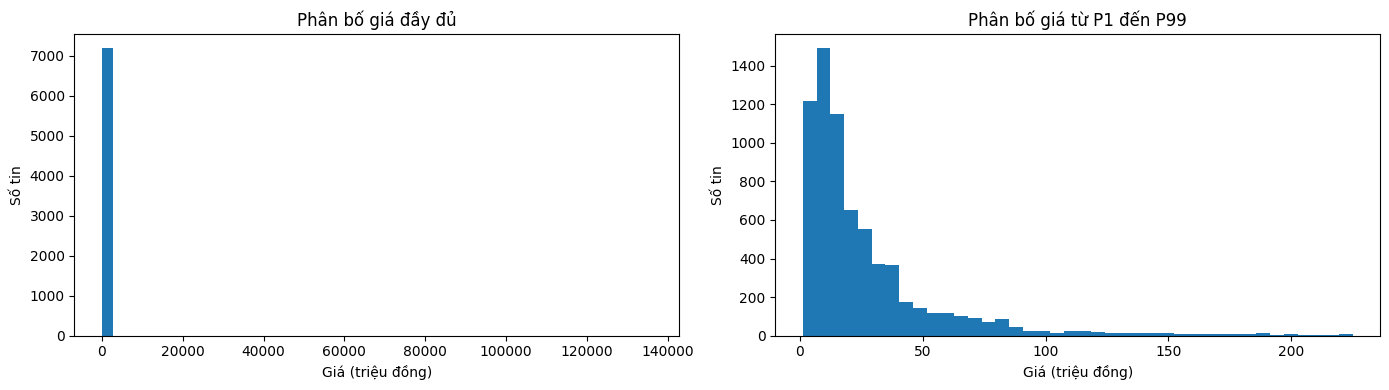

In [22]:
# Vẽ phân bố giá đầy đủ và phần giá từ P1 đến P99.

p01 = anomaly_df["price_million"].quantile(0.01)
p99 = anomaly_df["price_million"].quantile(0.99)
price_middle = anomaly_df[
    anomaly_df["price_million"].between(p01, p99)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(anomaly_df["price_million"], bins=50)
axes[0].set_title("Phân bố giá đầy đủ")
axes[0].set_xlabel("Giá (triệu đồng)")
axes[0].set_ylabel("Số tin")

axes[1].hist(price_middle["price_million"], bins=40)
axes[1].set_title("Phân bố giá từ P1 đến P99")
axes[1].set_xlabel("Giá (triệu đồng)")
axes[1].set_ylabel("Số tin")

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ phân bố giá

- Giá có phân bố **lệch phải rất mạnh**: trung vị là **16.5 triệu**, P90 là **65.0 triệu** và P99 là **225.0 triệu**.
- Giá lớn nhất là **136,000 triệu đồng**, cho thấy dữ liệu có lỗi nhập giá hoặc trường hợp cực đoan.
- Vì vậy biểu đồ đầy đủ bị kéo dài về bên phải. Biểu đồ P1-P99 giúp quan sát rõ hơn nhóm xe phổ biến.
- Mô hình chỉ học từ vùng 1-1.000 triệu, nhưng các giá dương ngoài vùng này vẫn được giữ để hệ thống phát hiện bất thường.

In [23]:
# Thống kê 10 thương hiệu có nhiều tin nhất.

brand_summary = (
    anomaly_df.groupby("brand")
    .agg(
        number_of_ads=("id", "count"),
        median_price=("price_million", "median"),
    )
    .sort_values("number_of_ads", ascending=False)
    .head(10)
)

display(brand_summary)

,number_of_ads,median_price
brand,,
Honda,4365,19.000
Yamaha,1411,13.500
Piaggio,380,25.000
Suzuki,280,17.000
SYM,256,4.500
Hãng khác,231,6.000
Kawasaki,60,41.000
Kymco,28,8.600
Ducati,16,130.000


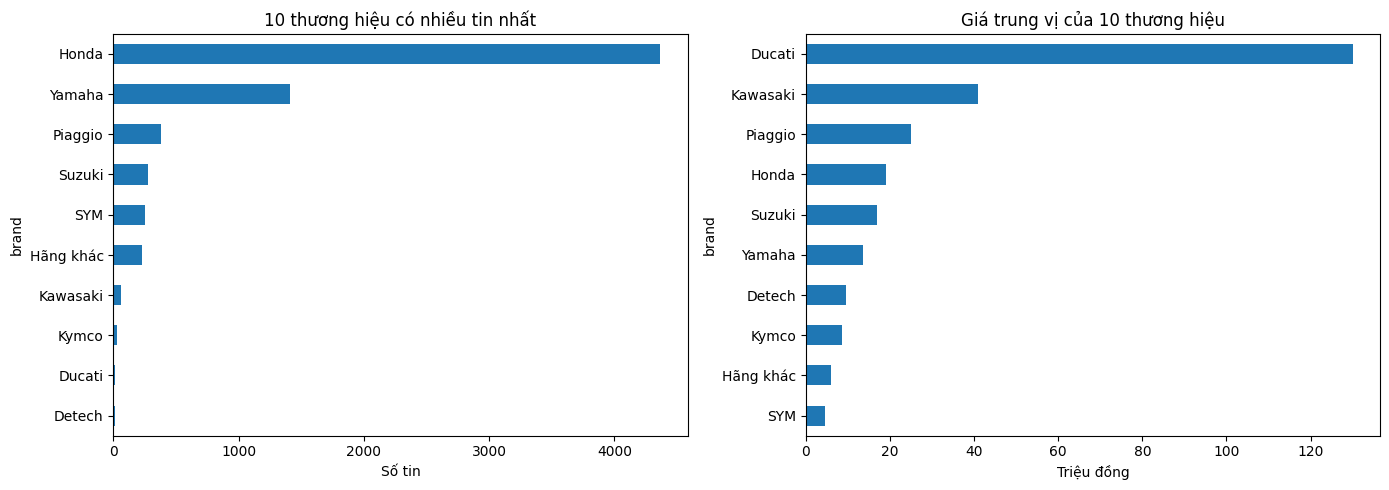

In [24]:
# Vẽ số lượng tin và giá trung vị theo thương hiệu.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_summary["number_of_ads"].sort_values().plot(
    kind="barh",
    ax=axes[0],
)
axes[0].set_title("10 thương hiệu có nhiều tin nhất")
axes[0].set_xlabel("Số tin")

brand_summary["median_price"].sort_values().plot(
    kind="barh",
    ax=axes[1],
)
axes[1].set_title("Giá trung vị của 10 thương hiệu")
axes[1].set_xlabel("Triệu đồng")

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ thương hiệu

- **Honda** chiếm nhiều nhất với **4,365 tin**, giá trung vị **19.0 triệu đồng**.
- Yamaha đứng thứ hai về số tin nhưng giá trung vị thấp hơn Honda.
- Ducati và Kawasaki có ít tin hơn nhưng giá trung vị cao hơn rõ rệt; điều này cho thấy không thể dùng một mặt bằng giá chung cho mọi thương hiệu.
- Sự khác nhau về quy mô và giá giữa các hãng là một lý do cần xây dựng phân khúc trước khi phát hiện bất thường.

In [25]:
# Kiểm tra hai khoảng giá ước tính có sẵn.

range_check = anomaly_df[
    ["price_million", "provided_min_million", "provided_max_million"]
].dropna()

train_range_check = range_check[
    range_check["price_million"].between(1, 1000)
]

provided_min_corr = range_check["price_million"].corr(
    range_check["provided_min_million"]
)
provided_max_corr = range_check["price_million"].corr(
    range_check["provided_max_million"]
)

train_min_corr = train_range_check["price_million"].corr(
    train_range_check["provided_min_million"]
)
train_max_corr = train_range_check["price_million"].corr(
    train_range_check["provided_max_million"]
)

within_provided_range = (
    train_range_check["price_million"].between(
        train_range_check["provided_min_million"],
        train_range_check["provided_max_million"],
    )
).mean()

print("Correlation trên toàn bộ giá dương:")
print("- Khoảng giá min:", provided_min_corr)
print("- Khoảng giá max:", provided_max_corr)

print("\nCorrelation trong vùng train 1-1000 triệu:")
print("- Khoảng giá min:", train_min_corr)
print("- Khoảng giá max:", train_max_corr)
print("- Tỷ lệ giá nằm trong khoảng có sẵn:", within_provided_range)

Correlation trên toàn bộ giá dương:
- Khoảng giá min: 0.0413100186115846
- Khoảng giá max: 0.041310458828247416

Correlation trong vùng train 1-1000 triệu:
- Khoảng giá min: 0.7678018291856444
- Khoảng giá max: 0.7678038949913684
- Tỷ lệ giá nằm trong khoảng có sẵn: 0.2817225983004465


### Nhận xét về khoảng giá có sẵn

- Trên toàn bộ dữ liệu giá dương, correlation chỉ khoảng **0.041** vì các lỗi giá cực lớn làm méo kết quả.
- Trong vùng train 1-1.000 triệu, correlation tăng lên khoảng **0.768**, cho thấy hai khoảng giá có liên quan mạnh với target.
- Tuy nhiên, chỉ **28.17%** giá thực nằm trong khoảng min-max có sẵn.
- Quan trọng hơn, đây là giá ước tính rất gần target và có thể không tồn tại khi dự đoán một tin mới. Vì nguy cơ **data leakage**, notebook không dùng hai cột này làm feature.

## 6.2. Motorbike Segmentation

Phân khúc được tạo theo dữ liệu thay vì dùng một ngưỡng chung cho toàn bộ xe:

1. ưu tiên `Thương hiệu + Dòng xe + Khoảng năm`;
2. nếu nhóm quá nhỏ, dùng `Thương hiệu + Loại xe`;
3. nếu vẫn quá nhỏ, dùng `Loại xe + Dung tích xe`;
4. các nhóm còn lại được đưa vào `Nhóm hiếm`.

Mục tiêu là giữ các xe tương đối giống nhau trong cùng phân khúc nhưng không chia nhóm quá nhỏ.

In [26]:
# Chia năm đăng ký thành các khoảng.

year_bins = [-np.inf, 1999, 2009, 2014, 2019, np.inf]
year_labels = [
    "Trước 2000",
    "2000-2009",
    "2010-2014",
    "2015-2019",
    "2020-2025",
]

anomaly_df["year_band"] = pd.cut(
    anomaly_df["year"],
    bins=year_bins,
    labels=year_labels,
).astype(str)

anomaly_df["year_band"] = anomaly_df["year_band"].replace("nan", "Không rõ")

In [27]:
# Tạo phân khúc chi tiết.

MIN_SEGMENT_SIZE = 24

anomaly_df["segment_detail"] = (
    anomaly_df["brand"]
    + " | "
    + anomaly_df["model"]
    + " | "
    + anomaly_df["year_band"]
)

detail_counts = anomaly_df["segment_detail"].value_counts()
anomaly_df["segment"] = anomaly_df["segment_detail"]

In [28]:
# Nhóm nhỏ được gộp theo thương hiệu và loại xe.

small_detail = anomaly_df["segment_detail"].map(detail_counts) < MIN_SEGMENT_SIZE

anomaly_df.loc[small_detail, "segment"] = (
    anomaly_df.loc[small_detail, "brand"]
    + " | "
    + anomaly_df.loc[small_detail, "bike_type"]
)

In [29]:
# Nếu vẫn nhỏ, tiếp tục gộp theo loại xe và dung tích.

segment_counts = anomaly_df["segment"].value_counts()
small_segment = anomaly_df["segment"].map(segment_counts) < MIN_SEGMENT_SIZE

anomaly_df.loc[small_segment, "segment"] = (
    anomaly_df.loc[small_segment, "bike_type"]
    + " | "
    + anomaly_df.loc[small_segment, "capacity"]
)

In [30]:
# Các nhóm còn quá nhỏ được gộp thành Nhóm hiếm.

segment_counts = anomaly_df["segment"].value_counts()
small_segment = anomaly_df["segment"].map(segment_counts) < MIN_SEGMENT_SIZE
anomaly_df.loc[small_segment, "segment"] = "Nhóm hiếm"

anomaly_df["segment_size"] = anomaly_df.groupby("segment")["id"].transform("size")
segment_sizes = anomaly_df["segment"].value_counts()

print("Số phân khúc:", len(segment_sizes))
print("Kích thước nhỏ nhất:", segment_sizes.min())
print("Kích thước trung vị:", segment_sizes.median())
print("Kích thước lớn nhất:", segment_sizes.max())

display(segment_sizes.head(15).to_frame("Số tin"))

Số phân khúc: 93
Kích thước nhỏ nhất: 24
Kích thước trung vị: 51.0
Kích thước lớn nhất: 255


,Số tin
segment,
Honda | Wave | 2000-2009,255
Honda | Air Blade | 2010-2014,249
Honda | Xe số,203
Honda | Tay côn/Moto,199
Honda | SH | 2015-2019,194
Honda | Tay ga,192
Yamaha | Exciter | 2015-2019,190
Honda | SH | 2020-2025,186
Honda | Wave | 2010-2014,182


### Nhận xét phân khúc

- Sau các bước gộp nhóm, dữ liệu có **93 phân khúc**.
- Mỗi phân khúc có ít nhất **24 tin**, trung vị **51 tin** và lớn nhất **255 tin**.
- Các nhóm lớn như Honda Wave, Honda Air Blade, Honda SH và Yamaha Exciter được giữ chi tiết theo khoảng năm.
- Nhóm hiếm được gộp rộng hơn để median, MAD và percentile không được tính từ quá ít mẫu.

In [31]:
# Ghép thông tin phân khúc vào dữ liệu huấn luyện.

segment_columns = ["id", "year_band", "segment", "segment_size"]

model_df = model_df.drop(
    columns=["year_band", "segment", "segment_size"],
    errors="ignore",
)
model_df = model_df.merge(
    anomaly_df[segment_columns],
    on="id",
    how="left",
)

### Lựa chọn cách sử dụng phân khúc

Notebook **không train 93 mô hình regression riêng biệt**, vì nhiều phân khúc chỉ có vài chục tin và mô hình riêng dễ thiếu ổn định. Thay vào đó:

- mô hình dự đoán giá dùng các thuộc tính `brand`, `model`, `bike_type`, `capacity`, `year/age` để học khác biệt giữa các nhóm xe;
- residual, MAD và percentile của bài toán bất thường được tính **riêng theo từng phân khúc**;
- cách này tránh so xe phổ thông với xe cao cấp nhưng vẫn giữ đủ dữ liệu cho mô hình regression chung.

# 7. Bài toán 1 - Dự đoán giá xe máy cũ

Mục tiêu là xây dựng mô hình regression để gợi ý giá đăng bán. Bài toán được thực hiện riêng trên scikit-learn và Spark ML. Trong mỗi môi trường, năm mô hình được đánh giá bằng MAE, RMSE và R²; mô hình có MAE thấp nhất được chọn để tiếp tục.

## 7.1. Chuẩn bị train/test dùng chung

Ablation và các mô hình chính sử dụng cùng một train/test split để kết quả có thể so sánh trực tiếp.

In [32]:
# Chọn các nhóm feature.

numeric_features = [
    "age",
    "km",
    "title_length",
    "description_length",
]

base_categorical_features = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
]

# Segment được tạo từ EDA và có sẵn khi dự đoán.
segment_categorical_features = base_categorical_features + ["segment"]

X_all = model_df[numeric_features + segment_categorical_features].copy()
y = model_df["price_million"].copy()

In [33]:
# Chia train/test một lần và lưu id để Spark dùng đúng cùng tập test.

price_groups = pd.qcut(y, q=10, duplicates="drop")

train_index, test_index = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=SEED,
    stratify=price_groups,
)

train_ids = set(model_df.loc[train_index, "id"])
test_ids = set(model_df.loc[test_index, "id"])

X_train_all = X_all.loc[train_index]
X_test_all = X_all.loc[test_index]
y_train = y.loc[train_index]
y_test = y.loc[test_index]

print("Train rows:", len(train_index))
print("Test rows:", len(test_index))

Train rows: 5712
Test rows: 1429


In [34]:
# Hàm tạo pipeline tiền xử lý đơn giản.

def create_preprocessor(categorical_columns, dense_output=True):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=3,
            sparse_output=not dense_output,
        )),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_columns),
    ])


def create_sklearn_pipeline(model, categorical_columns):
    return Pipeline([
        ("preprocessor", create_preprocessor(categorical_columns)),
        ("model", model),
    ])

## 7.2. Ablation test có/không có segment

Random Forest được giữ nguyên cấu hình trong hai lần chạy; chỉ khác việc có thêm feature `segment` hay không.

In [35]:
# Cấu hình Random Forest dùng cho ablation.

ablation_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=22,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=SEED,
)

### Biến đổi target

Giá có phân phối lệch phải và có một số xe giá rất cao. Vì vậy target
được biến đổi bằng `log1p(price)` trước khi train để giảm ảnh hưởng của
các giá cực đoan. Prediction được đổi ngược về triệu đồng bằng `expm1`
trước khi tính MAE, RMSE và R².

In [36]:
# Chạy ablation trên scikit-learn.

sklearn_ablation_rows = []

for setting_name, categorical_columns in {
    "Không segment": base_categorical_features,
    "Có segment": segment_categorical_features,
}.items():
    feature_columns = numeric_features + categorical_columns

    ablation_model = create_sklearn_pipeline(
        clone(ablation_rf),
        categorical_columns,
    )
    ablation_model.fit(
        X_train_all[feature_columns],
        np.log1p(y_train),
    )

    prediction = np.maximum(
        0,
        np.expm1(ablation_model.predict(X_test_all[feature_columns])),
    )

    sklearn_ablation_rows.append({
        "Thiết lập": setting_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": mean_squared_error(y_test, prediction) ** 0.5,
        "R2": r2_score(y_test, prediction),
    })

sklearn_ablation_df = pd.DataFrame(sklearn_ablation_rows)
display(sklearn_ablation_df.round(3))

,Thiết lập,MAE,RMSE,R2
0,Không segment,10.206,33.717,0.450
1,Có segment,10.151,33.287,0.464


In [37]:
# Chọn feature set có MAE thấp hơn cho phần scikit-learn.

best_ablation_setting = (
    sklearn_ablation_df
    .sort_values("MAE")
    .iloc[0]["Thiết lập"]
)

if best_ablation_setting == "Có segment":
    categorical_features = segment_categorical_features
else:
    categorical_features = base_categorical_features

model_features = numeric_features + categorical_features
X_train = X_train_all[model_features]
X_test = X_test_all[model_features]

print("Feature set được chọn:", best_ablation_setting)

Feature set được chọn: Có segment


### Nhận xét ablation scikit-learn

- Thêm `segment` làm MAE giảm từ **10.206** xuống **10.151 triệu đồng**.
- RMSE cũng giảm **33.717 → 33.287**, còn R² tăng **0.450 → 0.464**.
- Mức cải thiện không lớn nhưng nhất quán trên cả ba chỉ số. Vì vậy scikit-learn giữ `segment` trong feature set.

## 7.3. Môi trường Machine Learning truyền thống - scikit-learn

In [38]:
# Khai báo 5 mô hình regression.

sklearn_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=16,
        min_samples_leaf=3,
        random_state=SEED,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=22,
        min_samples_leaf=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=SEED,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        loss="huber",
        random_state=SEED,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        min_samples_leaf=2,
        max_features=0.9,
        n_jobs=-1,
        random_state=SEED,
    ),
}

In [39]:
# Train và đánh giá từng model trên đơn vị triệu đồng.

sklearn_results = []
sklearn_fitted_models = {}

y_train_log = np.log1p(y_train)

for model_name, estimator in sklearn_models.items():
    start_time = time.time()

    pipeline = create_sklearn_pipeline(
        clone(estimator),
        categorical_features,
    )
    pipeline.fit(X_train, y_train_log)

    prediction = np.maximum(
        0,
        np.expm1(pipeline.predict(X_test)),
    )

    sklearn_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": mean_squared_error(y_test, prediction) ** 0.5,
        "R2": r2_score(y_test, prediction),
        "Seconds": time.time() - start_time,
    })
    sklearn_fitted_models[model_name] = pipeline
    print("Completed:", model_name)

sklearn_results_df = (
    pd.DataFrame(sklearn_results)
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

display(sklearn_results_df.round(3))

best_sklearn_name = sklearn_results_df.loc[0, "Model"]
best_sklearn_model = sklearn_fitted_models[best_sklearn_name]
print("Best scikit-learn model:", best_sklearn_name)

Completed: Linear Regression
Completed: Decision Tree
Completed: Random Forest
Completed: Gradient Boosting
Completed: Extra Trees


,Model,MAE,RMSE,R2,Seconds
0,Random Forest,10.129,33.262,0.465,6.660
1,Extra Trees,10.425,32.745,0.482,18.971
2,Linear Regression,11.363,31.483,0.521,0.814
3,Gradient Boosting,11.796,35.558,0.389,10.081
4,Decision Tree,12.099,36.550,0.354,0.434


Best scikit-learn model: Random Forest


### Nhận xét kết quả scikit-learn

- Theo tiêu chí chính MAE, mô hình được chọn là **Random Forest** với MAE **10.129 triệu đồng**, RMSE **33.262** và R² **0.465**.
- Extra Trees và Linear Regression có RMSE/R² tốt hơn nhưng MAE cao hơn. Điều này cho thấy thứ hạng mô hình phụ thuộc metric; project ưu tiên MAE vì dễ diễn giải thành sai lệch giá trung bình.

### 7.3.1. Actual vs Predicted và Residual Plot

In [40]:
# Tạo bảng kết quả test của mô hình tốt nhất.

best_prediction = np.maximum(
    0,
    np.expm1(best_sklearn_model.predict(X_test)),
)

sklearn_test_result = model_df.loc[test_index, [
    "id",
    "segment",
    "price_million",
]].copy()

sklearn_test_result["predicted_price"] = best_prediction
sklearn_test_result["residual"] = (
    sklearn_test_result["price_million"]
    - sklearn_test_result["predicted_price"]
)

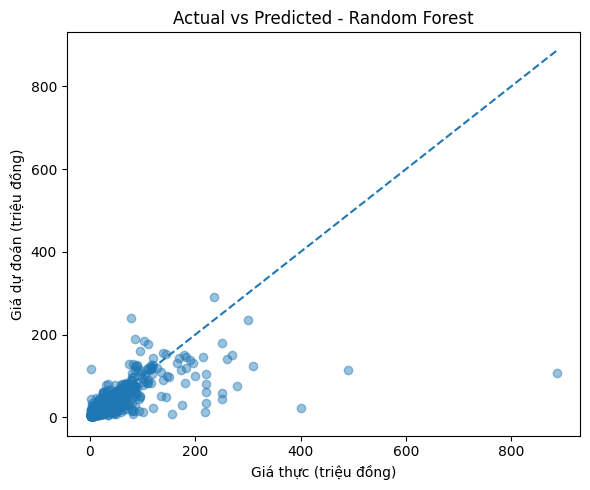

In [41]:
# Actual vs Predicted.

plt.figure(figsize=(6, 5))
plt.scatter(
    sklearn_test_result["price_million"],
    sklearn_test_result["predicted_price"],
    alpha=0.45,
)

max_price = max(
    sklearn_test_result["price_million"].max(),
    sklearn_test_result["predicted_price"].max(),
)
plt.plot([0, max_price], [0, max_price], linestyle="--")
plt.xlabel("Giá thực (triệu đồng)")
plt.ylabel("Giá dự đoán (triệu đồng)")
plt.title(f"Actual vs Predicted - {best_sklearn_name}")
plt.tight_layout()
plt.show()

### Nhận xét biểu đồ Actual vs Predicted

- Phần lớn xe phổ thông tập trung gần đường chéo, cho thấy dự đoán tương đối sát ở vùng giá thấp và trung bình.
- Các điểm giá rất cao nằm xa đường chéo hơn; mô hình có xu hướng kéo dự đoán về mặt bằng chung.
- Vì vậy cần xem thêm sai số theo nhóm giá và theo phân khúc, không chỉ dựa vào metric toàn cục.

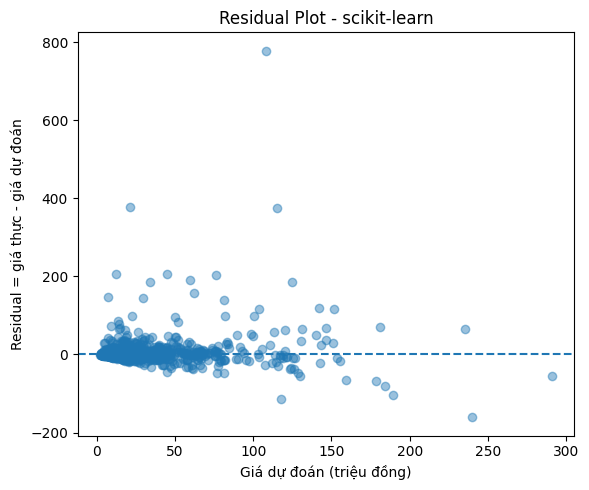

In [42]:
# Residual Plot.

plt.figure(figsize=(6, 5))
plt.scatter(
    sklearn_test_result["predicted_price"],
    sklearn_test_result["residual"],
    alpha=0.45,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Giá dự đoán (triệu đồng)")
plt.ylabel("Residual = giá thực - giá dự đoán")
plt.title("Residual Plot - scikit-learn")
plt.tight_layout()
plt.show()

### Nhận xét Residual Plot

- Residual phân tán rộng hơn khi giá dự đoán tăng, cho thấy phương sai sai số không đồng đều.
- Một số residual dương rất lớn là các xe có giá thực cao hơn nhiều so với mô hình; đây cũng là các ứng viên quan trọng cho anomaly detection.
- Residual không phân bố đều hoàn toàn quanh 0. Mô hình vẫn gặp khó ở nhóm xe đắt, hiếm hoặc có đặc điểm không được mô tả đầy đủ.

### 7.3.2. Sai số theo nhóm giá và theo phân khúc

In [43]:
# MAE theo nhóm giá.

sklearn_test_result["price_group"] = pd.cut(
    sklearn_test_result["price_million"],
    bins=[-np.inf, 10, 30, 100, np.inf],
    labels=["<10 triệu", "10-30 triệu", "30-100 triệu", ">100 triệu"],
)

sklearn_price_group_metrics = (
    sklearn_test_result
    .groupby("price_group", observed=False)
    .apply(lambda group: pd.Series({
        "N": len(group),
        "MAE": mean_absolute_error(
            group["price_million"],
            group["predicted_price"],
        ),
        "RMSE": mean_squared_error(
            group["price_million"],
            group["predicted_price"],
        ) ** 0.5,
    }))
    .reset_index()
)

display(sklearn_price_group_metrics.round(3))

,price_group,N,MAE,RMSE
0,<10 triệu,447.000,3.548,7.837
1,10-30 triệu,599.000,4.666,7.104
2,30-100 triệu,324.000,14.808,23.029
3,>100 triệu,59.000,89.764,151.347


### Nhận xét sai số theo nhóm giá

- MAE tăng rõ theo mức giá: **3.548 triệu** ở nhóm dưới 10 triệu và **4.666 triệu** ở nhóm 10-30 triệu.
- Nhóm 30-100 triệu có MAE **14.808 triệu**.
- Nhóm trên 100 triệu chỉ có 59 dòng test nhưng MAE lên tới **89.764 triệu**.
- Vì vậy một MAE chung chưa mô tả hết chất lượng mô hình; nhóm xe giá cao vẫn là hạn chế chính.

In [44]:
# Sai số theo phân khúc, chỉ hiển thị nhóm có ít nhất 10 dòng test.
# Tính MAE và relative MAE theo phân khúc trên test set.

sklearn_segment_metrics = (
    sklearn_test_result.groupby("segment")
    .apply(lambda group: pd.Series({
        "number_of_rows": len(group),
        "median_price": group["price_million"].median(),
        "MAE": mean_absolute_error(
            group["price_million"],
            group["predicted_price"],
        ),
    }))
    .reset_index()
)

sklearn_segment_metrics["relative_MAE"] = (
    sklearn_segment_metrics["MAE"]
    / sklearn_segment_metrics["median_price"].replace(0, np.nan)
)

sklearn_segment_metrics_valid = sklearn_segment_metrics[
    sklearn_segment_metrics["number_of_rows"] >= 10
].copy()

display(
    sklearn_segment_metrics_valid
    .sort_values("number_of_rows", ascending=False)
    .head(12)
    .round(3)
)

,segment,number_of_rows,median_price,MAE,relative_MAE
37,Honda | Wave | 2000-2009,47.000,9.100,4.784,0.526
2,Honda | Air Blade | 2010-2014,45.000,12.000,3.824,0.319
44,Honda | Xe số,45.000,10.000,9.295,0.930
73,Yamaha | Exciter | 2010-2014,43.000,17.500,9.830,0.562
31,Honda | Tay ga,42.000,28.750,15.256,0.531
27,Honda | SH | 2010-2014,38.000,96.500,32.959,0.342
30,Honda | Tay côn/Moto,38.000,25.900,22.154,0.855
28,Honda | SH | 2015-2019,37.000,68.800,11.676,0.170
53,Piaggio | Tay ga,35.000,25.000,8.839,0.354
42,Honda | Winner X | 2020-2025,34.000,23.500,3.240,0.138


In [45]:
# Các phân khúc có relative MAE cao nhất.

display(
    sklearn_segment_metrics_valid
    .sort_values("relative_MAE", ascending=False)
    .head(10)
    .round(3)
)

,segment,number_of_rows,median_price,MAE,relative_MAE
66,Suzuki | Xe số,14.000,7.250,32.251,4.448
64,Suzuki | Tay côn/Moto,31.000,23.000,29.765,1.294
8,Honda | Cub | Trước 2000,19.000,12.000,13.642,1.137
68,Tay côn/Moto | Trên 175 cc,14.000,101.500,114.033,1.123
12,Honda | Dòng khác | 2000-2009,10.000,10.600,11.692,1.103
45,Hãng khác | Dòng khác | 2000-2009,20.000,4.000,4.058,1.014
44,Honda | Xe số,45.000,10.000,9.295,0.930
9,Honda | Dream | 2000-2009,14.000,11.850,10.251,0.865
30,Honda | Tay côn/Moto,38.000,25.900,22.154,0.855
67,Tay côn/Moto | 100 - 175 cc,12.000,14.250,10.563,0.741


### Nhận xét sai số theo phân khúc - scikit-learn

- Sai số khác nhau rất mạnh giữa các phân khúc, nên MAE chung không đủ để mô tả chất lượng mô hình.
- Các phân khúc phổ biến như `Honda | Winner X | 2020-2025` và `Honda | Wave | 2010-2014` có sai số tương đối thấp hơn.
- Một số nhóm `Suzuki | Xe số`, `Suzuki | Tay côn/Moto` và xe trên 175 cc có relative MAE cao do giá phân tán mạnh và có ít mẫu cao cấp/hiếm.
- Kết quả này xác nhận nhận xét của giáo viên: một MAE toàn cục không đủ để mô tả chất lượng cho mọi phân khúc.

### 7.3.3. Feature Importance

In [46]:
# Lấy feature importance hoặc độ lớn coefficient.

feature_names = best_sklearn_model[
    "preprocessor"
].get_feature_names_out()

model_step = best_sklearn_model["model"]

if hasattr(model_step, "feature_importances_"):
    importance_values = model_step.feature_importances_
else:
    importance_values = np.abs(model_step.coef_)

sklearn_feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(sklearn_feature_importance.head(15))

,feature,importance
0,categorical__model_SH,0.239
1,numeric__age,0.231
2,categorical__capacity_Trên 175 cc,0.073
3,numeric__km,0.040
4,numeric__description_length,0.039
5,categorical__bike_type_Xe số,0.034
6,numeric__title_length,0.027
7,categorical__bike_type_Tay côn/Moto,0.023
8,categorical__brand_Honda,0.020
9,categorical__model_Exciter,0.019


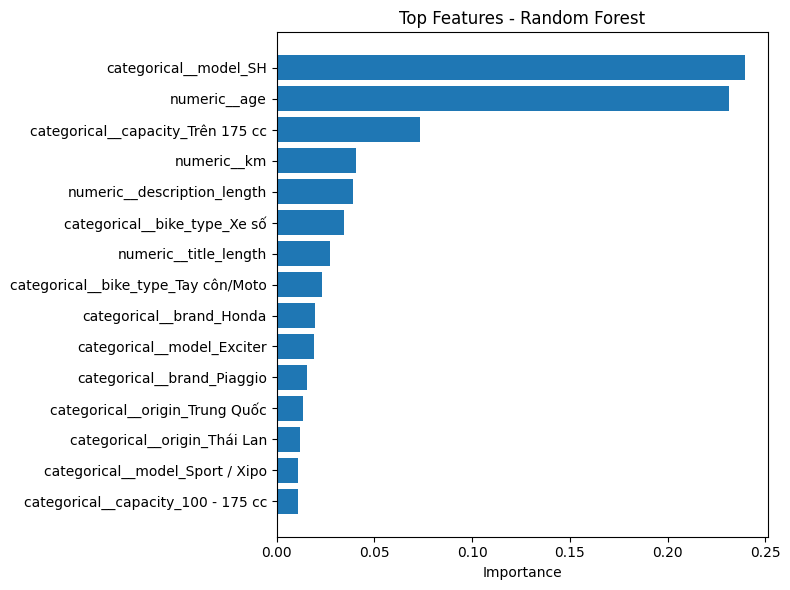

In [47]:
# Vẽ 15 feature quan trọng nhất.

sklearn_top_features = (
    sklearn_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(
    sklearn_top_features["feature"],
    sklearn_top_features["importance"],
)
plt.xlabel("Importance")
plt.title(f"Top Features - {best_sklearn_name}")
plt.tight_layout()
plt.show()

### Nhận xét Feature Importance scikit-learn

- Ba feature quan trọng nhất của Random Forest là **dòng SH**, **tuổi xe** và **dung tích trên 175 cc**.
- `km`, độ dài mô tả và loại xe cũng đóng góp nhưng thấp hơn.
- Feature importance chỉ cho biết mức đóng góp vào dự đoán của mô hình, không chứng minh quan hệ nhân quả.

## 7.4. Môi trường Big Data - Spark ML

In [48]:
# Import Spark ML.

from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import (
    OneHotEncoder as SparkOneHotEncoder,
    StandardScaler as SparkStandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.regression import (
    DecisionTreeRegressor as SparkDecisionTreeRegressor,
    GBTRegressor,
    GeneralizedLinearRegression,
    LinearRegression as SparkLinearRegression,
    RandomForestRegressor as SparkRandomForestRegressor,
)
from pyspark.sql import SparkSession, functions as F, types as T

In [49]:
# Tạo SparkSession

spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("Motorbike_Project_2")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.ui.enabled", "false")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.3


In [50]:
# Ghi dữ liệu sạch ra CSV để Spark đọc ổn định.

all_categorical_features = segment_categorical_features
all_model_features = numeric_features + all_categorical_features

spark_model_pdf = model_df[
    ["id", "price_million"] + all_model_features
].copy()

spark_model_pdf["dataset_split"] = np.where(
    spark_model_pdf["id"].isin(test_ids),
    "test",
    "train",
)

for column in all_categorical_features:
    spark_model_pdf[column] = (
        spark_model_pdf[column]
        .fillna("Không rõ")
        .astype(str)
    )

for column in numeric_features:
    spark_model_pdf[column] = pd.to_numeric(
        spark_model_pdf[column],
        errors="coerce",
    ).fillna(model_df[column].median())

SPARK_MODEL_CSV = OUTPUT_DIR / "spark_model_data.csv"
spark_model_pdf.to_csv(SPARK_MODEL_CSV, index=False)

In [51]:
# Tạo Spark DataFrame và giữ đúng train/test id.

spark_df = (
    spark.createDataFrame(spark_model_pdf)
    .withColumn(
        "label_log",
        F.log(F.col("price_million") + F.lit(1.0)),
    )
)

spark_train = spark_df.filter(F.col("dataset_split") == "train")
spark_test = spark_df.filter(F.col("dataset_split") == "test")

print("Spark train rows:", spark_train.count())
print("Spark test rows:", spark_test.count())

Spark train rows: 5712
Spark test rows: 1429


In [52]:
# Hàm fit pipeline tiền xử lý Spark cho một danh sách feature phân loại.

def fit_spark_preprocessor(train_df, categorical_columns):
    indexers = []
    indexed_columns = []

    for column in categorical_columns:
        indexed_column = f"{column}_index"
        indexers.append(StringIndexer(
            inputCol=column,
            outputCol=indexed_column,
            handleInvalid="keep",
        ))
        indexed_columns.append(indexed_column)

    encoded_columns = [
        f"{column}_encoded"
        for column in categorical_columns
    ]

    encoder = SparkOneHotEncoder(
        inputCols=indexed_columns,
        outputCols=encoded_columns,
        handleInvalid="keep",
    )

    assembler = VectorAssembler(
        inputCols=numeric_features + encoded_columns,
        outputCol="features",
        handleInvalid="keep",
    )

    pipeline = SparkPipeline(
        stages=indexers + [encoder, assembler]
    )

    return pipeline.fit(train_df)

### 7.4.1. Ablation test Spark có/không có segment

In [53]:
# Chạy Random Forest cùng cấu hình cho hai feature set.

spark_ablation_rows = []
spark_ablation_models = {}

for setting_name, categorical_columns in {
    "Không segment": base_categorical_features,
    "Có segment": segment_categorical_features,
}.items():
    preprocessing_model = fit_spark_preprocessor(
        spark_train,
        categorical_columns,
    )

    train_prepared = preprocessing_model.transform(spark_train)
    test_prepared = preprocessing_model.transform(spark_test)

    ablation_model = SparkRandomForestRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        numTrees=12,
        maxDepth=7,
        minInstancesPerNode=2,
        featureSubsetStrategy="0.8",
        seed=SEED,
    ).fit(train_prepared)

    prediction_df = (
        ablation_model
        .transform(test_prepared)
        .withColumn(
            "predicted_price",
            F.greatest(
                F.lit(0.0),
                F.exp(F.col("prediction_log")) - F.lit(1.0),
            ),
        )
    )

    row_result = {"Thiết lập": setting_name}

    for metric_name in ["mae", "rmse", "r2"]:
        evaluator = RegressionEvaluator(
            labelCol="price_million",
            predictionCol="predicted_price",
            metricName=metric_name,
        )
        row_result[metric_name.upper()] = evaluator.evaluate(
            prediction_df
        )

    spark_ablation_rows.append(row_result)
    spark_ablation_models[setting_name] = preprocessing_model

spark_ablation_df = pd.DataFrame(spark_ablation_rows)
display(spark_ablation_df.round(3))

,Thiết lập,MAE,RMSE,R2
0,Không segment,11.785,33.974,0.442
1,Có segment,11.604,34.422,0.427


In [54]:
# Chọn feature set có MAE thấp hơn cho Spark.

best_spark_ablation_setting = (
    spark_ablation_df
    .sort_values("MAE")
    .iloc[0]["Thiết lập"]
)

if best_spark_ablation_setting == "Có segment":
    spark_categorical_features = segment_categorical_features
else:
    spark_categorical_features = base_categorical_features

spark_preprocess_model = fit_spark_preprocessor(
    spark_train,
    spark_categorical_features,
)

spark_train_prepared = spark_preprocess_model.transform(
    spark_train
).cache()
spark_test_prepared = spark_preprocess_model.transform(
    spark_test
).cache()

print("Spark feature set được chọn:", best_spark_ablation_setting)

Spark feature set được chọn: Có segment


### Nhận xét ablation Spark

- Thêm `segment` làm MAE giảm từ **11.785** xuống **11.604 triệu đồng**.
- Tuy nhiên RMSE tăng **33.974 → 34.422** và R² giảm **0.442 → 0.427**.
- Vì project chọn mô hình theo MAE và phân khúc còn cần cho anomaly detection, Spark tiếp tục dùng `segment`.

### 7.4.2. Huấn luyện 5 mô hình Spark ML

In [55]:
# Khai báo 5 mô hình Spark ML.

spark_models = {
    "Linear Regression": SparkLinearRegression(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        maxIter=80,
        regParam=0.01,
    ),
    "Generalized Linear Regression": GeneralizedLinearRegression(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        family="gaussian",
        link="identity",
        maxIter=40,
        regParam=0.01,
    ),
    "Decision Tree": SparkDecisionTreeRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        maxDepth=10,
        minInstancesPerNode=3,
        seed=SEED,
    ),
    "Random Forest": SparkRandomForestRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        numTrees=60,
        maxDepth=12,
        minInstancesPerNode=2,
        featureSubsetStrategy="0.8",
        seed=SEED,
    ),
    "Gradient-Boosted Trees": GBTRegressor(
        featuresCol="features",
        labelCol="label_log",
        predictionCol="prediction_log",
        maxIter=35,
        maxDepth=5,
        stepSize=0.05,
        seed=SEED,
    ),
}

In [56]:
# Train và đánh giá từng mô hình Spark.

spark_results = []
spark_fitted_models = {}

for model_name, estimator in spark_models.items():
    start_time = time.time()

    fitted_model = estimator.fit(spark_train_prepared)
    prediction_df = (
        fitted_model
        .transform(spark_test_prepared)
        .withColumn(
            "predicted_price",
            F.greatest(
                F.lit(0.0),
                F.exp(F.col("prediction_log")) - F.lit(1.0),
            ),
        )
    )

    row_result = {"Model": model_name}

    for metric_name in ["mae", "rmse", "r2"]:
        evaluator = RegressionEvaluator(
            labelCol="price_million",
            predictionCol="predicted_price",
            metricName=metric_name,
        )
        row_result[metric_name.upper()] = evaluator.evaluate(
            prediction_df
        )

    row_result["Seconds"] = time.time() - start_time
    spark_results.append(row_result)
    spark_fitted_models[model_name] = fitted_model
    print("Completed:", model_name)

spark_results_df = (
    pd.DataFrame(spark_results)
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)

display(spark_results_df.round(3))

best_spark_name = spark_results_df.loc[0, "Model"]
best_spark_model = spark_fitted_models[best_spark_name]
print("Best Spark model:", best_spark_name)

Completed: Linear Regression
Completed: Generalized Linear Regression
Completed: Decision Tree
Completed: Random Forest
Completed: Gradient-Boosted Trees


,Model,MAE,RMSE,R2,Seconds
0,Random Forest,10.543,33.431,0.460,74.292
1,Linear Regression,11.237,30.587,0.548,4.182
2,Generalized Linear Regression,11.237,30.587,0.548,1.735
3,Gradient-Boosted Trees,11.474,33.248,0.466,31.461
4,Decision Tree,11.862,38.708,0.276,5.731


Best Spark model: Random Forest


### Nhận xét kết quả Spark ML

- Theo MAE, mô hình Spark được chọn là **Random Forest**
- Random Forest có MAE thấp nhất: 10.543 triệu đồng.
- Linear Regression có RMSE thấp hơn
  (30.587 triệu) và R² cao hơn (0.548).
- Project chọn Random Forest vì MAE được xác định là metric chính,
  tức ưu tiên giảm sai lệch tuyệt đối trung bình theo triệu đồng.

### 7.4.3. Actual vs Predicted và Residual Plot cho Spark

In [57]:
# Lấy kết quả test của mô hình Spark tốt nhất.

spark_best_test_prediction = (
    best_spark_model
    .transform(spark_test_prepared)
    .withColumn(
        "predicted_price",
        F.greatest(
            F.lit(0.0),
            F.exp(F.col("prediction_log")) - F.lit(1.0),
        ),
    )
    .withColumn(
        "residual",
        F.col("price_million") - F.col("predicted_price"),
    )
)

spark_test_result = (
    spark_best_test_prediction
    .select(
        "id",
        "segment",
        "price_million",
        "predicted_price",
        "residual",
    )
    .toPandas()
)

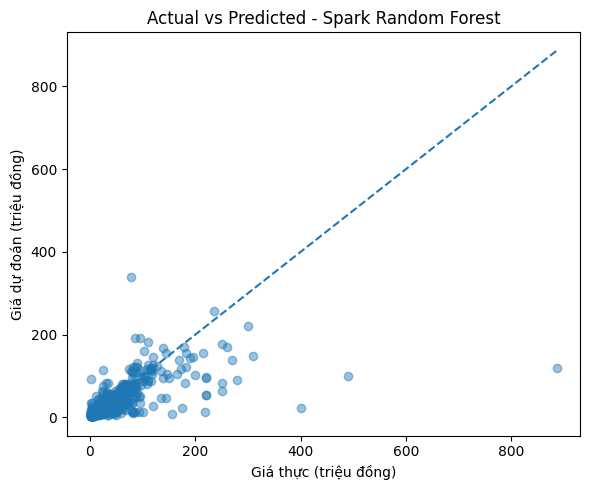

In [58]:
# Actual vs Predicted - Spark.

plt.figure(figsize=(6, 5))
plt.scatter(
    spark_test_result["price_million"],
    spark_test_result["predicted_price"],
    alpha=0.45,
)

max_price = max(
    spark_test_result["price_million"].max(),
    spark_test_result["predicted_price"].max(),
)
plt.plot([0, max_price], [0, max_price], linestyle="--")
plt.xlabel("Giá thực (triệu đồng)")
plt.ylabel("Giá dự đoán (triệu đồng)")
plt.title(f"Actual vs Predicted - Spark {best_spark_name}")
plt.tight_layout()
plt.show()

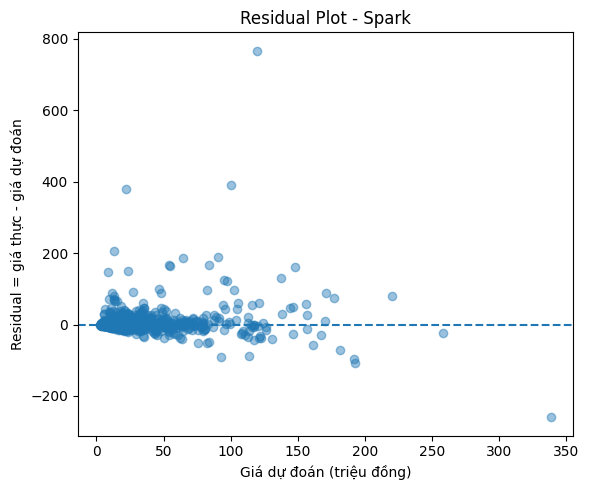

In [59]:
# Residual Plot - Spark.

plt.figure(figsize=(6, 5))
plt.scatter(
    spark_test_result["predicted_price"],
    spark_test_result["residual"],
    alpha=0.45,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Giá dự đoán (triệu đồng)")
plt.ylabel("Residual = giá thực - giá dự đoán")
plt.title("Residual Plot - Spark")
plt.tight_layout()
plt.show()

### Nhận xét hai biểu đồ Spark

- Hình dạng hai biểu đồ Spark tương tự scikit-learn: vùng giá thấp được dự đoán sát hơn, còn sai số tăng ở xe giá cao.
- Nhiều điểm giá thực cao nằm dưới đường chéo, thể hiện xu hướng dự đoán thấp đối với một số xe hiếm hoặc cao cấp.
- Residual Plot có các điểm dương rất lớn và một số điểm âm lớn; đây là lý do cần phân tích sai số theo phân khúc và dùng residual cho bài toán bất thường.

### 7.4.4. Sai số theo phân khúc trên Spark

In [60]:
# MAE và relative MAE theo phân khúc trên Spark test set.

spark_segment_metrics = (
    spark_best_test_prediction
    .withColumn(
        "absolute_error",
        F.abs(F.col("price_million") - F.col("predicted_price")),
    )
    .groupBy("segment")
    .agg(
        F.count("*").alias("number_of_rows"),
        F.expr(
            "percentile_approx(price_million, 0.5, 10000)"
        ).alias("median_price"),
        F.avg("absolute_error").alias("MAE"),
    )
    .withColumn(
        "relative_MAE",
        F.col("MAE") / F.col("median_price"),
    )
    .filter(F.col("number_of_rows") >= 10)
)

display(
    spark_segment_metrics
    .orderBy(F.col("MAE").desc())
    .limit(12)
    .toPandas()
    .round(3)
)

display(
    spark_segment_metrics
    .orderBy(F.col("relative_MAE").desc())
    .limit(10)
    .toPandas()
    .round(3)
)

,segment,number_of_rows,median_price,MAE,relative_MAE
0,Tay côn/Moto | Trên 175 cc,14,99.999,117.059,1.171
1,Suzuki | Tay côn/Moto,31,23.000,32.440,1.410
2,Suzuki | Xe số,14,6.500,30.146,4.638
3,Honda | SH | 2010-2014,38,95.000,29.735,0.313
4,Honda | Tay côn/Moto,38,25.000,23.442,0.938
5,Yamaha | Tay côn/Moto,14,28.000,19.077,0.681
6,Honda | Tay ga,42,25.000,18.352,0.734
7,Honda | SH | 2000-2009,16,45.000,16.351,0.363
8,Honda | SH | 2020-2025,29,83.000,13.702,0.165
9,Honda | Cub | Trước 2000,19,12.000,13.640,1.137


,segment,number_of_rows,median_price,MAE,relative_MAE
0,Suzuki | Xe số,14,6.500,30.146,4.638
1,Honda | Dream | 2000-2009,14,6.700,11.312,1.688
2,Suzuki | Tay côn/Moto,31,23.000,32.440,1.410
3,Honda | Dòng khác | 2000-2009,10,10.200,12.016,1.178
4,Tay côn/Moto | Trên 175 cc,14,99.999,117.059,1.171
5,Honda | Cub | Trước 2000,19,12.000,13.640,1.137
6,Hãng khác | Dòng khác | 2000-2009,20,4.000,4.326,1.081
7,Honda | Tay côn/Moto,38,25.000,23.442,0.938
8,Honda | Xe số,45,10.000,8.975,0.898
9,Tay côn/Moto | 100 - 175 cc,12,13.000,11.241,0.865


### Nhận xét sai số Spark theo phân khúc

- Sai số khác nhau rõ rệt giữa các phân khúc. Nhóm `Tay côn/Moto | Trên 175 cc` có MAE cao nhất, khoảng 117 triệu đồng, cho thấy mô hình chưa ổn định với xe phân khối lớn và khoảng giá rộng.

- Nhóm `Suzuki | Xe số` có relative MAE cao nhất (4.638), nghĩa là sai số lớn gấp nhiều lần giá trung vị của phân khúc. Ngược lại, các nhóm Honda SH có MAE tuyệt đối khá cao nhưng relative MAE thấp hơn do mức giá xe cao.

- Nhìn chung, mô hình hoạt động tốt hơn ở các phân khúc phổ biến và gặp khó khăn với nhóm ít dữ liệu, xe cũ, xe hiếm hoặc có giá biến động mạnh.

### 7.4.5. Feature Importance của Spark Random Forest

In [61]:
# Lấy tên từng feature từ metadata của vector Spark.

feature_metadata = spark_train_prepared.schema[
    "features"
].metadata["ml_attr"]["attrs"]

spark_feature_names = {}

for attribute_type in feature_metadata.values():
    for attribute in attribute_type:
        spark_feature_names[attribute["idx"]] = attribute["name"]

spark_rf_model = spark_fitted_models["Random Forest"]
spark_rf_importance_values = spark_rf_model.featureImportances.toArray()

spark_feature_importance = pd.DataFrame({
    "feature": [
        spark_feature_names[index]
        for index in range(len(spark_rf_importance_values))
    ],
    "importance": spark_rf_importance_values,
}).sort_values("importance", ascending=False)

display(spark_feature_importance.head(15))

,feature,importance
43,model_encoded_SH,0.270
0,age,0.248
231,capacity_encoded_Trên 175 cc,0.087
226,bike_type_encoded_Xe số,0.039
1,km,0.023
3,description_length,0.022
227,bike_type_encoded_Tay côn/Moto,0.021
4,brand_encoded_Honda,0.021
46,model_encoded_Exciter,0.021
6,brand_encoded_Piaggio,0.018


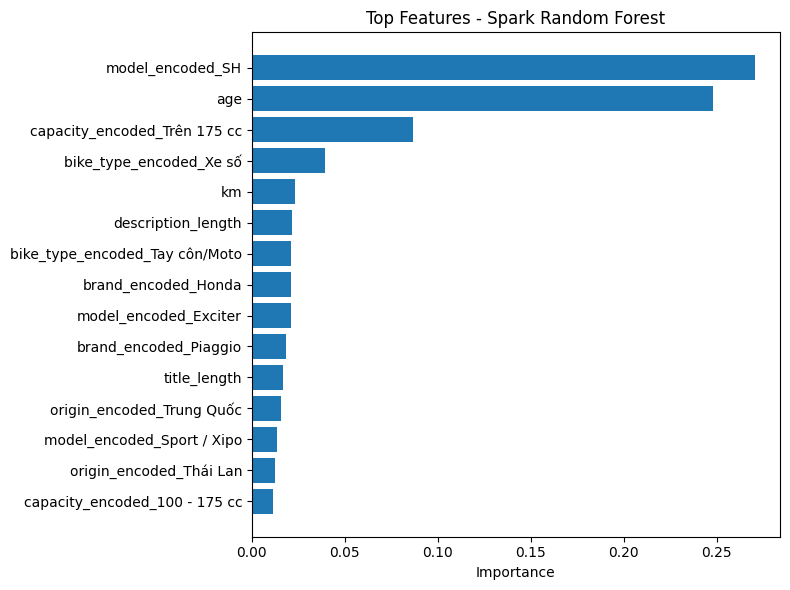

In [62]:
# Vẽ 15 feature quan trọng nhất của Spark Random Forest.

spark_top_features = (
    spark_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(
    spark_top_features["feature"],
    spark_top_features["importance"],
)
plt.xlabel("Importance")
plt.title("Top Features - Spark Random Forest")
plt.tight_layout()
plt.show()

### Nhận xét Feature Importance Spark

- Random Forest Spark cũng xếp **dòng SH**, **tuổi xe** và **dung tích trên 175 cc** ở ba vị trí đầu.
- Kết quả tương đồng với scikit-learn về nhóm feature quan trọng, dù giá trị importance không cần giống nhau do cách xây dựng cây khác nhau.
- Việc bổ sung feature importance giúp phần Spark đáp ứng yêu cầu giải thích mô hình thay vì chỉ báo cáo metric.

## 7.5. Kết luận Bài toán 1

- Ablation cho thấy `segment` giảm MAE ở cả hai môi trường, nhưng tác động lên RMSE/R² của Spark không hoàn toàn cùng chiều.
- Mô hình chính theo MAE là **Random Forest** ở cả scikit-learn và Spark ML.
- scikit-learn đạt MAE **10.129 triệu**, Spark đạt **10.543 triệu**. Hai con số chỉ được báo cáo riêng, không dùng để xếp hạng hai môi trường.
- Sai số theo phân khúc cho thấy nhóm xe trên 175 cc khó dự đoán nhất; khi triển khai nên hiển thị thêm phân khúc và cảnh báo độ tin cậy.

# 8. Bài toán 2 - Phát hiện bất thường giá

Năm tín hiệu:

1. Residual-Z.
2. P1-P99.
3. P10-P90.
4. Unsupervised.
5. Điểm tổng hợp 0-100 và ngưỡng top-k%.

## 8.1. scikit-learn

### 8.1.1. Out-of-fold prediction cho residual

In [63]:
# Dự đoán 5-fold OOF cho các dòng dùng huấn luyện.

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
best_model_template = clone(sklearn_models[best_sklearn_name])

oof_prediction_log = cross_val_predict(
    create_sklearn_pipeline(
        best_model_template,
        categorical_features,
    ),
    model_df[model_features],
    np.log1p(model_df["price_million"]),
    cv=cv,
    n_jobs=1,
)

model_df["sklearn_predicted_price"] = np.maximum(
    0,
    np.expm1(oof_prediction_log),
)

In [64]:
# Fit model cuối cùng để dự đoán các giá nằm ngoài vùng train.

final_sklearn_model = create_sklearn_pipeline(
    clone(sklearn_models[best_sklearn_name]),
    categorical_features,
)
final_sklearn_model.fit(
    model_df[model_features],
    np.log1p(model_df["price_million"]),
)

anomaly_result = anomaly_df.copy()
anomaly_result = anomaly_result.merge(
    model_df[["id", "sklearn_predicted_price"]],
    on="id",
    how="left",
)

missing_prediction = anomaly_result[
    "sklearn_predicted_price"
].isna()

outside_prediction = np.maximum(
    0,
    np.expm1(final_sklearn_model.predict(
        anomaly_result.loc[missing_prediction, model_features]
    )),
)

anomaly_result.loc[
    missing_prediction,
    "sklearn_predicted_price",
] = outside_prediction

anomaly_result["residual"] = (
    anomaly_result["price_million"]
    - anomaly_result["sklearn_predicted_price"]
)

### 8.1.2. Tín hiệu 1 - Residual-Z

In [65]:
# Median residual và MAD theo phân khúc.

def median_absolute_deviation(series):
    median_value = series.median()
    return np.median(np.abs(series - median_value))

segment_residual_median = (
    anomaly_result
    .groupby("segment")["residual"]
    .median()
    .rename("residual_median")
)

segment_mad = (
    anomaly_result
    .groupby("segment")["residual"]
    .apply(median_absolute_deviation)
    .rename("residual_mad")
)

anomaly_result = anomaly_result.join(
    segment_residual_median,
    on="segment",
)
anomaly_result = anomaly_result.join(
    segment_mad,
    on="segment",
)

In [66]:
# Gắn cờ khi |Residual-Z| >= 3.

global_mad = median_absolute_deviation(anomaly_result["residual"])
fallback_scale = max(1.4826 * global_mad, 1.0)

segment_scale = 1.4826 * anomaly_result["residual_mad"]
segment_scale = segment_scale.where(
    segment_scale > 0,
    fallback_scale,
)

anomaly_result["residual_z"] = (
    anomaly_result["residual"]
    - anomaly_result["residual_median"]
) / segment_scale

anomaly_result["flag_residual_z"] = (
    anomaly_result["residual_z"].abs() >= 3
)

### 8.1.3. Tín hiệu 2 và 3 - P1/P99 và P10/P90

In [67]:
# Tính percentile giá theo từng phân khúc.

segment_percentiles = (
    anomaly_result
    .groupby("segment")["price_million"]
    .quantile([0.01, 0.10, 0.90, 0.99])
    .unstack()
    .rename(columns={
        0.01: "p01",
        0.10: "p10",
        0.90: "p90",
        0.99: "p99",
    })
)

anomaly_result = anomaly_result.join(
    segment_percentiles,
    on="segment",
)

anomaly_result["flag_minmax"] = (
    (anomaly_result["price_million"] < anomaly_result["p01"])
    | (anomaly_result["price_million"] > anomaly_result["p99"])
)

anomaly_result["flag_common_range"] = (
    (anomaly_result["price_million"] < anomaly_result["p10"])
    | (anomaly_result["price_million"] > anomaly_result["p90"])
)

### 8.1.4. Tín hiệu 4 - Isolation Forest với feature số và phân loại

In [68]:
# Isolation Forest dùng cả thông tin kỹ thuật và categorical feature.

isolation_numeric_features = [
    "age",
    "km",
    "title_length",
    "description_length",
    "sklearn_predicted_price",
    "residual_z",
]

isolation_categorical_features = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
    "segment",
]

isolation_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        isolation_numeric_features,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5,
            )),
        ]),
        isolation_categorical_features,
    ),
])

isolation_matrix = isolation_preprocessor.fit_transform(
    anomaly_result[
        isolation_numeric_features
        + isolation_categorical_features
    ]
)

In [69]:
# Fit Isolation Forest và lấy score.

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=SEED,
    n_jobs=-1,
)

isolation_forest.fit(isolation_matrix)

anomaly_result["isolation_raw_score"] = -isolation_forest.score_samples(
    isolation_matrix
)
anomaly_result["flag_isolation"] = (
    isolation_forest.predict(isolation_matrix) == -1
)

### 8.1.5. Tín hiệu 5 - Điểm tổng hợp

In [70]:
# Chuẩn hóa bốn tín hiệu thành s1-s4.

anomaly_result["s1_residual"] = (
    anomaly_result["residual_z"].abs() / 6
).clip(0, 1)

anomaly_result["s2_minmax"] = anomaly_result[
    "flag_minmax"
].astype(float)

below_p10 = (
    anomaly_result["p10"] - anomaly_result["price_million"]
).clip(lower=0)

above_p90 = (
    anomaly_result["price_million"] - anomaly_result["p90"]
).clip(lower=0)

common_width = (
    anomaly_result["p90"] - anomaly_result["p10"]
).replace(0, np.nan)

anomaly_result["s3_common_range"] = (
    np.maximum(below_p10, above_p90) / common_width
).fillna(0).clip(0, 1)

isolation_min = anomaly_result["isolation_raw_score"].min()
isolation_max = anomaly_result["isolation_raw_score"].max()

anomaly_result["s4_isolation"] = (
    anomaly_result["isolation_raw_score"] - isolation_min
) / (isolation_max - isolation_min)

In [71]:
# Điểm tổng hợp và top 5%.

anomaly_result["sklearn_anomaly_score"] = 100 * (
    0.40 * anomaly_result["s1_residual"]
    + 0.20 * anomaly_result["s2_minmax"]
    + 0.20 * anomaly_result["s3_common_range"]
    + 0.20 * anomaly_result["s4_isolation"]
)

sklearn_anomaly_threshold = anomaly_result[
    "sklearn_anomaly_score"
].quantile(0.95)

anomaly_result["sklearn_is_anomaly"] = (
    anomaly_result["sklearn_anomaly_score"]
    >= sklearn_anomaly_threshold
)

anomaly_result["sklearn_anomaly_type"] = np.where(
    anomaly_result["residual"] < 0,
    "Quá rẻ",
    "Quá đắt",
)

In [72]:
# Tạo bảng từng cờ và lý do cho scikit-learn.

def create_sklearn_reason(row):
    reasons = []

    if row["flag_residual_z"]:
        reasons.append(f"Residual-Z = {row['residual_z']:.2f}")
    if row["flag_minmax"]:
        reasons.append("Giá ngoài P1-P99")
    if row["flag_common_range"]:
        reasons.append("Giá ngoài P10-P90")
    if row["flag_isolation"]:
        reasons.append("Isolation Forest đánh dấu")

    return "; ".join(reasons) if reasons else "Điểm tổng hợp cao"

component_flags = [
    "flag_residual_z",
    "flag_minmax",
    "flag_common_range",
    "flag_isolation",
]

anomaly_result["sklearn_flag_count"] = anomaly_result[
    component_flags
].sum(axis=1)

anomaly_result["sklearn_reason"] = anomaly_result.apply(
    create_sklearn_reason,
    axis=1,
)

In [73]:
# Tóm tắt anomaly detection scikit-learn.

sklearn_anomaly_summary = pd.Series({
    "Ngưỡng top 5%": sklearn_anomaly_threshold,
    "Số tin bị gắn cờ": anomaly_result["sklearn_is_anomaly"].sum(),
    "Quá rẻ": (
        anomaly_result["sklearn_is_anomaly"]
        & (anomaly_result["sklearn_anomaly_type"] == "Quá rẻ")
    ).sum(),
    "Quá đắt": (
        anomaly_result["sklearn_is_anomaly"]
        & (anomaly_result["sklearn_anomaly_type"] == "Quá đắt")
    ).sum(),
    "Cờ Residual-Z": anomaly_result["flag_residual_z"].sum(),
    "Cờ P1-P99": anomaly_result["flag_minmax"].sum(),
    "Cờ P10-P90": anomaly_result["flag_common_range"].sum(),
    "Cờ Isolation Forest": anomaly_result["flag_isolation"].sum(),
})

display(sklearn_anomaly_summary.to_frame("Kết quả"))

,Kết quả
Ngưỡng top 5%,49.652
Số tin bị gắn cờ,360.000
Quá rẻ,108.000
Quá đắt,252.000
Cờ Residual-Z,580.000
Cờ P1-P99,236.000
Cờ P10-P90,"1,451.000"
Cờ Isolation Forest,360.000


- Residual-Z được đặt trọng số 0.40 vì đây là tín hiệu trực tiếp đo chênh
lệch giữa giá thực và giá của mô hình tốt nhất. Ba tín hiệu còn lại
được đặt 0.20 để bổ sung thông tin thị trường và cấu trúc dữ liệu.

- Các trọng số hiện là lựa chọn heuristic vì dữ liệu không có ground truth
anomaly để tối ưu trọng số.

In [74]:
# Xem 20 tin có score scikit-learn cao nhất.

sklearn_top_anomalies = (
    anomaly_result
    .sort_values("sklearn_anomaly_score", ascending=False)
    [[
        "id",
        "title",
        "segment",
        "price_million",
        "sklearn_predicted_price",
        "flag_residual_z",
        "flag_minmax",
        "flag_common_range",
        "flag_isolation",
        "sklearn_flag_count",
        "sklearn_anomaly_score",
        "sklearn_anomaly_type",
        "sklearn_reason",
    ]]
    .head(20)
)

display(sklearn_top_anomalies.round(3))

,id,title,segment,price_million,sklearn_predicted_price,flag_residual_z,flag_minmax,flag_common_range,flag_isolation,sklearn_flag_count,sklearn_anomaly_score,sklearn_anomaly_type,sklearn_reason
2661,2665,🏍️- #Honda_Africa_Twin_Adventure_Sport 1100 ABS .,Honda | Dòng khác | 2020-2025,490.000,125.756,True,True,True,True,4,98.044,Quá đắt,Residual-Z = 20.27; Giá ngoài P1-P99; Giá ngoà...
1668,1671,Em nhượng lại cho ae 1 xe bền-keng-bs vip 😍,Honda | Wave | 2020-2025,82.000,17.950,True,True,True,True,4,95.948,Quá đắt,Residual-Z = 17.79; Giá ngoài P1-P99; Giá ngoà...
6743,6757,Bán xe mô tô,Honda | Tay côn/Moto,285.000,32.754,True,True,True,True,4,95.500,Quá đắt,Residual-Z = 22.96; Giá ngoài P1-P99; Giá ngoà...
5182,5195,Harley Davidson Streetglide special US chính chủ,Tay côn/Moto | Trên 175 cc,886.000,112.901,True,True,True,True,4,94.993,Quá đắt,Residual-Z = 7.22; Giá ngoài P1-P99; Giá ngoài...
3658,3662,"Bán xe moto CB919, đã lên full CB1100, xe rất đep",Honda | Tay côn/Moto,330.000,56.599,True,True,True,True,4,94.801,Quá đắt,Residual-Z = 24.89; Giá ngoài P1-P99; Giá ngoà...
813,816,Xe Thái hàng thùng,Honda | Dream | Trước 2000,110.000,15.498,True,True,True,True,4,94.255,Quá đắt,Residual-Z = 7.63; Giá ngoài P1-P99; Giá ngoài...
3988,3992,Honda vtx 1300 cc. Đời 2008. Hải quan chính ngạch,Honda | Dòng khác | 2000-2009,320.000,51.111,True,True,True,True,4,93.434,Quá đắt,Residual-Z = 45.17; Giá ngoài P1-P99; Giá ngoà...
4235,4239,"Bán xe Sh 350i, Máy thái , đăng ký 11/2022",Honda | SH | 2020-2025,"136,000.000",149.302,True,True,True,True,4,93.303,Quá đắt,Residual-Z = 10770.13; Giá ngoài P1-P99; Giá n...
7093,7109,Xmax 300 chính chủ sang tên,Yamaha | Tay ga,220.000,62.814,True,True,True,True,4,93.102,Quá đắt,Residual-Z = 27.68; Giá ngoài P1-P99; Giá ngoà...
4081,4085,"Xe SH300i mói 99,9% hàng hiếm không có chiếc t...",Honda | SH | 2015-2019,285.000,144.004,True,True,True,False,3,92.733,Quá đắt,Residual-Z = 14.10; Giá ngoài P1-P99; Giá ngoà...


In [75]:
sklearn_flagged = anomaly_result[
    anomaly_result["sklearn_is_anomaly"]
]

display(
    sklearn_flagged["sklearn_flag_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_flags")
    .to_frame("number_of_ads")
)

,number_of_ads
number_of_flags,
1,9
2,188
3,146
4,17


### Nhận xét anomaly detection scikit-learn

- Ngưỡng top 5% là **49.652 điểm**, tạo **360** tin cần kiểm tra: **108 quá rẻ** và **252 quá đắt**.
- Số cờ thành phần lần lượt là: Residual-Z **580**, P1-P99 **236**, P10-P90 **1,451**, Isolation Forest **360**.
- Trong 360 tin cuối, **351 tin có ít nhất 2/4 cờ**; chỉ 9 tin có một cờ. Điểm tổng hợp vì vậy chủ yếu ưu tiên các trường hợp được nhiều tín hiệu hỗ trợ.
- Isolation Forest đã dùng cả feature số và one-hot feature phân loại, đúng với yêu cầu vector gồm hãng, dòng, loại xe và residual/z.
- P10-P90 là dải phổ biến nên nhạy hơn P1-P99; cờ cuối cùng vẫn dựa trên điểm tổng hợp, không dựa vào riêng một tín hiệu.

## 8.2. PySpark

### 8.2.1. Spark out-of-fold prediction

In [76]:
# Chuẩn bị toàn bộ dữ liệu giá dương cho Spark anomaly detection.

spark_anomaly_pdf = anomaly_result[
    ["id", "title", "href", "price_million"]
    + all_model_features
].copy()

spark_anomaly_pdf["is_model_row"] = (
    spark_anomaly_pdf["price_million"].between(1, 1000)
).astype(int)

for column in all_categorical_features + ["title", "href"]:
    spark_anomaly_pdf[column] = (
        spark_anomaly_pdf[column]
        .fillna("Không rõ")
        .astype(str)
    )

for column in numeric_features:
    spark_anomaly_pdf[column] = pd.to_numeric(
        spark_anomaly_pdf[column],
        errors="coerce",
    ).fillna(model_df[column].median())

SPARK_ANOMALY_CSV = OUTPUT_DIR / "spark_anomaly_data.csv"
spark_anomaly_pdf.to_csv(SPARK_ANOMALY_CSV, index=False)

In [77]:
# Tạo Spark DataFrame và tiền xử lý toàn bộ dữ liệu.

spark_anomaly_raw = spark.createDataFrame(spark_anomaly_pdf)

spark_model_all_prepared = spark_preprocess_model.transform(
    spark_df
).cache()

spark_anomaly_prepared = spark_preprocess_model.transform(
    spark_anomaly_raw
).cache()

In [78]:
# Tạo dự đoán OOF 5-fold cho các dòng dùng huấn luyện.

SPARK_OOF_FOLDS = 5

# Chia fold bằng hash của id.
# Cách này ngẫu nhiên hơn so với lấy id % 5,
# nhưng vẫn cho kết quả giống nhau ở mỗi lần chạy.
spark_model_with_fold = spark_model_all_prepared.withColumn(
    "oof_fold",
    F.pmod(
        F.xxhash64("id"),
        F.lit(SPARK_OOF_FOLDS),
    ),
)

# Kiểm tra số dòng trong từng fold.
spark_model_with_fold.groupBy("oof_fold").count().orderBy(
    "oof_fold"
).show()

spark_oof_predictions = None

for fold_number in range(SPARK_OOF_FOLDS):
    print(
        f"Đang chạy fold {fold_number + 1}/{SPARK_OOF_FOLDS}"
    )

    # Dữ liệu dùng để train.
    fold_train = spark_model_with_fold.filter(
        F.col("oof_fold") != fold_number
    )

    # Dữ liệu dùng để tạo prediction ngoài mẫu.
    fold_valid = spark_model_with_fold.filter(
        F.col("oof_fold") == fold_number
    )

    # Train model trên 4/5 dữ liệu.
    fold_model = spark_models[best_spark_name].fit(
        fold_train
    )

    # Dự đoán 1/5 dữ liệu còn lại.
    fold_prediction = (
        fold_model
        .transform(fold_valid)
        .select(
            "id",
            F.greatest(
                F.lit(0.0),
                F.exp(F.col("prediction_log"))
                - F.lit(1.0),
            ).alias("spark_predicted_price"),
        )
    )

    # Ghép prediction của từng fold.
    if spark_oof_predictions is None:
        spark_oof_predictions = fold_prediction
    else:
        spark_oof_predictions = (
            spark_oof_predictions.unionByName(
                fold_prediction
            )
        )

# Cache vì bảng này còn được dùng ở các bước sau.
spark_oof_predictions = spark_oof_predictions.cache()

print(
    "Spark OOF predictions:",
    spark_oof_predictions.count(),
)

+--------+-----+
|oof_fold|count|
+--------+-----+
|       0| 1408|
|       1| 1468|
|       2| 1404|
|       3| 1437|
|       4| 1424|
+--------+-----+

Đang chạy fold 1/5
Đang chạy fold 2/5
Đang chạy fold 3/5
Đang chạy fold 4/5
Đang chạy fold 5/5
Spark OOF predictions: 7141


In [79]:
# Kiểm tra mỗi dòng huấn luyện có đúng một OOF prediction.

expected_oof_rows = (
    spark_model_all_prepared
    .select("id")
    .distinct()
    .count()
)

actual_oof_rows = (
    spark_oof_predictions
    .select("id")
    .distinct()
    .count()
)

invalid_oof_ids = (
    spark_oof_predictions
    .groupBy("id")
    .count()
    .filter(F.col("count") != 1)
    .count()
)

print("Expected OOF rows:", expected_oof_rows)
print("Actual OOF rows:", actual_oof_rows)
print("IDs không có đúng một prediction:", invalid_oof_ids)

if actual_oof_rows != expected_oof_rows:
    raise RuntimeError(
        "Số OOF prediction không khớp dữ liệu huấn luyện."
    )

if invalid_oof_ids != 0:
    raise RuntimeError(
        "Một số id không có đúng một OOF prediction."
    )


# Dự đoán các dòng ngoài vùng train bằng model
# được fit trên toàn bộ dữ liệu huấn luyện hợp lệ.

spark_best_full_model = spark_models[
    best_spark_name
].fit(
    spark_model_all_prepared
)

spark_outside_predictions = (
    spark_best_full_model
    .transform(
        spark_anomaly_prepared.filter(
            F.col("is_model_row") == 0
        )
    )
    .select(
        "id",
        F.greatest(
            F.lit(0.0),
            F.exp(F.col("prediction_log"))
            - F.lit(1.0),
        ).alias("spark_predicted_price"),
    )
)


# Ghép OOF prediction và prediction ngoài vùng train.

spark_all_predictions = (
    spark_oof_predictions.unionByName(
        spark_outside_predictions
    )
)


# Ghép prediction vào toàn bộ dữ liệu anomaly
# và tính residual.

spark_price_prediction = (
    spark_anomaly_prepared
    .join(
        spark_all_predictions,
        on="id",
        how="inner",
    )
    .withColumn(
        "residual",
        F.col("price_million")
        - F.col("spark_predicted_price"),
    )
)


# Kiểm tra số prediction cuối cùng.

spark_prediction_count = (
    spark_price_prediction.count()
)

if spark_prediction_count != len(anomaly_result):
    raise RuntimeError(
        "Spark prediction count không khớp dữ liệu anomaly."
    )

print("Spark predictions:", spark_prediction_count)

Expected OOF rows: 7141
Actual OOF rows: 7141
IDs không có đúng một prediction: 0
Spark predictions: 7193


### 8.2.2. Tín hiệu 1-3 theo phân khúc

In [80]:
# Median residual, MAD và percentile theo phân khúc.

spark_segment_median = spark_price_prediction.groupBy("segment").agg(
    F.expr(
        "percentile(residual, 0.5)"
    ).alias("residual_median")
)

spark_with_median = spark_price_prediction.join(
    spark_segment_median,
    on="segment",
    how="left",
)

spark_with_deviation = spark_with_median.withColumn(
    "absolute_deviation",
    F.abs(F.col("residual") - F.col("residual_median")),
)

spark_segment_mad = spark_with_deviation.groupBy("segment").agg(
    F.expr(
        "percentile(absolute_deviation, 0.5)"
    ).alias("residual_mad")
)

spark_segment_prices = spark_price_prediction.groupBy("segment").agg(
    F.expr("percentile(price_million, 0.01)").alias("p01"),
    F.expr("percentile(price_million, 0.10)").alias("p10"),
    F.expr("percentile(price_million, 0.90)").alias("p90"),
    F.expr("percentile(price_million, 0.99)").alias("p99"),
)

In [81]:
# Tính Residual-Z và ba cờ thống kê.

global_residual_median = spark_price_prediction.approxQuantile(
    "residual",
    [0.5],
    0.001,
)[0]

global_mad = (
    spark_price_prediction
    .withColumn(
        "global_deviation",
        F.abs(F.col("residual") - F.lit(global_residual_median)),
    )
    .approxQuantile("global_deviation", [0.5], 0.001)[0]
)

spark_fallback_scale = max(1.4826 * global_mad, 1.0)

spark_signals = (
    spark_with_deviation
    .join(spark_segment_mad, on="segment", how="left")
    .join(spark_segment_prices, on="segment", how="left")
    .withColumn(
        "residual_scale",
        F.when(
            F.col("residual_mad") > 0,
            1.4826 * F.col("residual_mad"),
        ).otherwise(F.lit(spark_fallback_scale)),
    )
    .withColumn(
        "residual_z",
        (F.col("residual") - F.col("residual_median"))
        / F.col("residual_scale"),
    )
    .withColumn(
        "flag_residual_z",
        F.abs(F.col("residual_z")) >= 3,
    )
    .withColumn(
        "flag_minmax",
        (F.col("price_million") < F.col("p01"))
        | (F.col("price_million") > F.col("p99")),
    )
    .withColumn(
        "flag_common_range",
        (F.col("price_million") < F.col("p10"))
        | (F.col("price_million") > F.col("p90")),
    )
)

### 8.2.3. Tín hiệu 4 - KMeans với vector feature đầy đủ

In [82]:
# Ghép toàn bộ vector kỹ thuật với giá dự đoán và Residual-Z.

kmeans_assembler = VectorAssembler(
    inputCols=[
        "features",
        "spark_predicted_price",
        "residual_z",
    ],
    outputCol="kmeans_raw_features",
    handleInvalid="keep",
)

spark_kmeans_vector = kmeans_assembler.transform(spark_signals)

kmeans_scaler = SparkStandardScaler(
    inputCol="kmeans_raw_features",
    outputCol="kmeans_features",
    withMean=False,
    withStd=True,
).fit(
    spark_kmeans_vector.filter(F.col("is_model_row") == 1)
)

spark_kmeans_scaled = kmeans_scaler.transform(
    spark_kmeans_vector
)

kmeans_model = KMeans(
    k=8,
    seed=SEED,
    featuresCol="kmeans_features",
    predictionCol="cluster",
).fit(
    spark_kmeans_scaled.filter(F.col("is_model_row") == 1)
)

spark_kmeans_scored = kmeans_model.transform(
    spark_kmeans_scaled
)

- Spark sử dụng khoảng cách đến tâm KMeans như tín hiệu unsupervised thay
thế. Điểm càng xa tâm cụm càng hiếm trong không gian đặc trưng.

- `k=8` là cấu hình thực nghiệm ban đầu; đây chưa phải số cụm tối ưu.
Phiên bản sau có thể so sánh nhiều giá trị k bằng Silhouette Score.

In [83]:
# Tính khoảng cách đến tâm cụm.

kmeans_centers = [
    center.tolist()
    for center in kmeans_model.clusterCenters()
]

@F.udf(returnType=T.DoubleType())
def distance_to_center(cluster, feature_array):
    center = np.array(kmeans_centers[int(cluster)])
    point = np.array(feature_array)
    return float(np.linalg.norm(point - center))

spark_kmeans_scored = (
    spark_kmeans_scored
    .withColumn(
        "kmeans_feature_array",
        vector_to_array("kmeans_features"),
    )
    .withColumn(
        "kmeans_distance",
        distance_to_center(
            F.col("cluster"),
            F.col("kmeans_feature_array"),
        ),
    )
)

kmeans_distance_threshold = spark_kmeans_scored.approxQuantile(
    "kmeans_distance",
    [0.95],
    0.001,
)[0]

### 8.2.4. Tín hiệu 5 - Điểm tổng hợp và bảng lý do

In [84]:
# Chuẩn hóa bốn tín hiệu và tính score.

spark_distance_stats = spark_kmeans_scored.agg(
    F.min("kmeans_distance").alias("distance_min"),
    F.max("kmeans_distance").alias("distance_max"),
).first()

distance_min = float(spark_distance_stats["distance_min"])
distance_max = float(spark_distance_stats["distance_max"])
distance_range = max(distance_max - distance_min, 1e-9)

spark_scored = (
    spark_kmeans_scored
    .withColumn(
        "s1_residual",
        F.least(F.abs(F.col("residual_z")) / 6, F.lit(1.0)),
    )
    .withColumn(
        "s2_minmax",
        F.col("flag_minmax").cast("double"),
    )
    .withColumn(
        "outside_distance",
        F.greatest(
            F.greatest(
                F.col("p10") - F.col("price_million"),
                F.lit(0.0),
            ),
            F.greatest(
                F.col("price_million") - F.col("p90"),
                F.lit(0.0),
            ),
        ),
    )
    .withColumn(
        "s3_common_range",
        F.when(
            F.col("p90") > F.col("p10"),
            F.least(
                F.col("outside_distance")
                / (F.col("p90") - F.col("p10")),
                F.lit(1.0),
            ),
        ).otherwise(F.lit(0.0)),
    )
    .withColumn(
        "s4_kmeans",
        (F.col("kmeans_distance") - F.lit(distance_min))
        / F.lit(distance_range),
    )
    .withColumn(
        "flag_kmeans",
        F.col("kmeans_distance") >= kmeans_distance_threshold,
    )
    .withColumn(
        "spark_anomaly_score",
        100 * (
            0.40 * F.col("s1_residual")
            + 0.20 * F.col("s2_minmax")
            + 0.20 * F.col("s3_common_range")
            + 0.20 * F.col("s4_kmeans")
        ),
    )
)

In [85]:
# Gắn cờ cuối cùng, đếm số cờ và tạo lý do.

spark_anomaly_threshold = spark_scored.approxQuantile(
    "spark_anomaly_score",
    [0.95],
    0.001,
)[0]

spark_scored = (
    spark_scored
    .withColumn(
        "spark_flag_count",
        F.col("flag_residual_z").cast("int")
        + F.col("flag_minmax").cast("int")
        + F.col("flag_common_range").cast("int")
        + F.col("flag_kmeans").cast("int"),
    )
    .withColumn(
        "spark_is_anomaly",
        F.col("spark_anomaly_score") >= spark_anomaly_threshold,
    )
    .withColumn(
        "spark_anomaly_type",
        F.when(F.col("residual") < 0, "Quá rẻ")
        .otherwise("Quá đắt"),
    )
    .withColumn(
        "spark_reason",
        F.concat_ws(
            "; ",
            F.when(
                F.col("flag_residual_z"),
                F.format_string(
                    "Residual-Z = %.2f",
                    F.col("residual_z"),
                ),
            ),
            F.when(
                F.col("flag_minmax"),
                F.lit("Giá ngoài P1-P99"),
            ),
            F.when(
                F.col("flag_common_range"),
                F.lit("Giá ngoài P10-P90"),
            ),
            F.when(
                F.col("flag_kmeans"),
                F.lit("Khoảng cách KMeans thuộc top 5%"),
            ),
        ),
    )
)

In [86]:
# Bảng từng cờ và lý do cho Spark.

spark_anomaly_result = (
    spark_scored
    .select(
        "id",
        "title",
        "href",
        "segment",
        "price_million",
        "spark_predicted_price",
        "residual",
        "residual_z",
        "p01",
        "p10",
        "p90",
        "p99",
        "flag_residual_z",
        "flag_minmax",
        "flag_common_range",
        "flag_kmeans",
        "spark_flag_count",
        "spark_anomaly_score",
        "spark_is_anomaly",
        "spark_anomaly_type",
        "spark_reason",
    )
    .orderBy(F.col("spark_anomaly_score").desc())
    .toPandas()
)

display(spark_anomaly_result.head(20).round(3))

,id,title,href,segment,price_million,spark_predicted_price,residual,residual_z,p01,p10,p90,p99,flag_residual_z,flag_minmax,flag_common_range,flag_kmeans,spark_flag_count,spark_anomaly_score,spark_is_anomaly,spark_anomaly_type,spark_reason
0,4239,"Bán xe Sh 350i, Máy thái , đăng ký 11/2022",https://xe.chotot.com/mua-ban-xe-may-quan-tan-...,Honda | SH | 2020-2025,"136,000.000",143.169,"135,856.831","11,094.061",0.865,66.400,122.900,290.250,True,True,True,True,4,100.000,True,Quá đắt,Residual-Z = 11094.06; Giá ngoài P1-P99; Giá n...
1,6445,Xe máy,https://xe.chotot.com/mua-ban-xe-may-huyen-bin...,Honda | Air Blade | 2000-2009,"3,500.000",10.284,"3,489.716","1,414.424",4.920,6.500,15.480,316.800,True,True,True,True,4,82.549,True,Quá đắt,Residual-Z = 1414.42; Giá ngoài P1-P99; Giá ng...
2,5200,Vento 150cc xe nhập bstp đẹp tứ quý 8888 có Gl...,https://xe.chotot.com/mua-ban-xe-may-thanh-pho...,Tay côn/Moto | 100 - 175 cc,83.500,15.213,68.287,11.007,3.951,5.000,38.200,71.995,True,True,True,True,4,80.731,True,Quá đắt,Residual-Z = 11.01; Giá ngoài P1-P99; Giá ngoà...
3,5233,chính chủ bán xe bmw r nite t,https://xe.chotot.com/mua-ban-xe-may-thanh-pho...,Nhóm hiếm,400.000,16.972,383.028,70.087,1.286,3.910,69.700,374.500,True,True,True,True,4,80.386,True,Quá đắt,Residual-Z = 70.09; Giá ngoài P1-P99; Giá ngoà...
4,7126,"CẦn bán xe ,400cc , odo 600 km",https://xe.chotot.com/mua-ban-xe-may-huyen-nha...,Piaggio | Tay ga,170.000,46.174,123.826,15.301,2.859,6.000,61.350,95.230,True,True,True,True,4,80.369,True,Quá đắt,Residual-Z = 15.30; Giá ngoài P1-P99; Giá ngoà...
5,3230,Bán đồ cỗ Yaz125 2016 Hqcn,https://xe.chotot.com/mua-ban-xe-may-quan-binh...,Yamaha | Tay côn/Moto,"2,000.000",38.122,"1,961.878",162.656,4.885,16.870,76.500,471.600,True,True,True,True,4,80.344,True,Quá đắt,Residual-Z = 162.66; Giá ngoài P1-P99; Giá ngo...
6,3405,Kẹt tiền bán xe tâm huyết,https://xe.chotot.com/mua-ban-xe-may-quan-binh...,Suzuki | Tay ga,45.600,6.203,39.397,15.007,1.604,2.540,16.600,40.262,True,True,True,True,4,80.311,True,Quá đắt,Residual-Z = 15.01; Giá ngoài P1-P99; Giá ngoà...
7,5195,Harley Davidson Streetglide special US chính chủ,https://xe.chotot.com/mua-ban-xe-may-thanh-pho...,Tay côn/Moto | Trên 175 cc,886.000,78.643,807.357,8.128,12.060,33.700,364.500,761.380,True,True,True,True,4,80.229,True,Quá đắt,Residual-Z = 8.13; Giá ngoài P1-P99; Giá ngoài...
8,6215,kẹt tiền bán gấp yaz thùng LƯỚT 800km HQTL sag...,https://xe.chotot.com/mua-ban-xe-may-huyen-bin...,Yamaha | Tay côn/Moto,480.000,86.558,393.442,32.118,4.885,16.870,76.500,471.600,True,True,True,False,3,80.192,True,Quá đắt,Residual-Z = 32.12; Giá ngoài P1-P99; Giá ngoà...
9,1563,Vespa 946 66666,https://xe.chotot.com/mua-ban-xe-may-quan-10-t...,Piaggio | Vespa | 2020-2025,890.000,64.869,825.131,89.893,3.379,45.300,77.900,417.250,True,True,True,False,3,80.184,True,Quá đắt,Residual-Z = 89.89; Giá ngoài P1-P99; Giá ngoà...


In [87]:
# Tóm tắt anomaly detection Spark.

spark_anomaly_summary = pd.Series({
    "Ngưỡng top 5%": spark_anomaly_threshold,
    "Số tin bị gắn cờ": spark_anomaly_result["spark_is_anomaly"].sum(),
    "Quá rẻ": (
        spark_anomaly_result["spark_is_anomaly"]
        & (spark_anomaly_result["spark_anomaly_type"] == "Quá rẻ")
    ).sum(),
    "Quá đắt": (
        spark_anomaly_result["spark_is_anomaly"]
        & (spark_anomaly_result["spark_anomaly_type"] == "Quá đắt")
    ).sum(),
    "Cờ Residual-Z": spark_anomaly_result["flag_residual_z"].sum(),
    "Cờ P1-P99": spark_anomaly_result["flag_minmax"].sum(),
    "Cờ P10-P90": spark_anomaly_result["flag_common_range"].sum(),
    "Cờ KMeans": spark_anomaly_result["flag_kmeans"].sum(),
})

display(spark_anomaly_summary.to_frame("Kết quả"))

,Kết quả
Ngưỡng top 5%,40.128
Số tin bị gắn cờ,367.000
Quá rẻ,108.000
Quá đắt,259.000
Cờ Residual-Z,581.000
Cờ P1-P99,236.000
Cờ P10-P90,"1,451.000"
Cờ KMeans,367.000


In [88]:
spark_flagged = spark_anomaly_result[
    spark_anomaly_result["spark_is_anomaly"]
]

display(
    spark_flagged["spark_flag_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_flags")
    .to_frame("number_of_ads")
)

,number_of_ads
number_of_flags,
1,6
2,204
3,145
4,12


### Nhận xét anomaly detection Spark

- Spark dùng dự đoán OOF **5-fold**, nên residual không được tính từ dự đoán in-sample của chính dòng dữ liệu.
- Ngưỡng score là **40.128**, tạo **367** tin: **108 quá rẻ** và **259 quá đắt**.
- Số cờ thành phần là: Residual-Z **581**, P1-P99 **236**, P10-P90 **1,451**, KMeans **367**. P1/P99 và P10/P90 dùng `percentile` chính xác để thống nhất với pandas.
- Trong 367 tin cuối, **361 tin có ít nhất 2/4 cờ**. Bảng kết quả lưu riêng từng cờ và lý do để người kiểm duyệt không chỉ nhận một nhãn “bất thường”.

## 8.3. Mức đồng thuận scikit-learn-Spark và case study

Hai môi trường không được dùng để kết luận môi trường nào “thắng”. Phần này chỉ đo mức nhất quán của hai danh sách cảnh báo khi không có ground truth.

In [89]:
# Ghép kết quả hai môi trường theo id.

agreement_df = anomaly_result[[
    "id",
    "title",
    "segment",
    "price_million",
    "sklearn_predicted_price",
    "sklearn_anomaly_score",
    "sklearn_is_anomaly",
    "sklearn_anomaly_type",
    "sklearn_reason",
]].merge(
    spark_anomaly_result[[
        "id",
        "spark_predicted_price",
        "spark_anomaly_score",
        "spark_is_anomaly",
        "spark_anomaly_type",
        "spark_reason",
    ]],
    on="id",
    how="inner",
)

agreement_table = pd.crosstab(
    agreement_df["sklearn_is_anomaly"],
    agreement_df["spark_is_anomaly"],
    rownames=["scikit-learn"],
    colnames=["Spark"],
)

display(agreement_table)

Spark,False,True
scikit-learn,,
False,6773,60
True,53,307


In [90]:
# Tính agreement rate và Jaccard cho tập anomaly.

same_flag = (
    agreement_df["sklearn_is_anomaly"]
    == agreement_df["spark_is_anomaly"]
)

both_anomaly = (
    agreement_df["sklearn_is_anomaly"]
    & agreement_df["spark_is_anomaly"]
)

either_anomaly = (
    agreement_df["sklearn_is_anomaly"]
    | agreement_df["spark_is_anomaly"]
)

agreement_rate = same_flag.mean()

if either_anomaly.sum() > 0:
    anomaly_jaccard = (
        both_anomaly.sum() / either_anomaly.sum()
    )
else:
    anomaly_jaccard = 1.0

agreement_summary = pd.Series({
    "Cùng gắn cờ anomaly": both_anomaly.sum(),
    "Chỉ scikit-learn": (
        agreement_df["sklearn_is_anomaly"]
        & ~agreement_df["spark_is_anomaly"]
    ).sum(),
    "Chỉ Spark": (
        ~agreement_df["sklearn_is_anomaly"]
        & agreement_df["spark_is_anomaly"]
    ).sum(),
    "Cùng không gắn cờ": (
        ~agreement_df["sklearn_is_anomaly"]
        & ~agreement_df["spark_is_anomaly"]
    ).sum(),
    "Agreement rate": agreement_rate,
    "Jaccard anomaly": anomaly_jaccard,
})

display(agreement_summary.to_frame("Kết quả"))

,Kết quả
Cùng gắn cờ anomaly,307.000
Chỉ scikit-learn,53.000
Chỉ Spark,60.000
Cùng không gắn cờ,"6,773.000"
Agreement rate,0.984
Jaccard anomaly,0.731


In [91]:
# Chọn case study tiêu biểu từ ba nhóm.

def select_cases(mask, number_of_rows=3):
    return (
        agreement_df[mask]
        .assign(
            average_score=lambda frame: (
                frame["sklearn_anomaly_score"]
                + frame["spark_anomaly_score"]
            ) / 2
        )
        .sort_values("average_score", ascending=False)
        .head(number_of_rows)
    )

cases_both = select_cases(
    agreement_df["sklearn_is_anomaly"]
    & agreement_df["spark_is_anomaly"]
)

cases_sklearn_only = select_cases(
    agreement_df["sklearn_is_anomaly"]
    & ~agreement_df["spark_is_anomaly"]
)

cases_spark_only = select_cases(
    ~agreement_df["sklearn_is_anomaly"]
    & agreement_df["spark_is_anomaly"]
)

case_studies = pd.concat([
    cases_both.assign(case_group="Cả hai cảnh báo"),
    cases_sklearn_only.assign(case_group="Chỉ scikit-learn"),
    cases_spark_only.assign(case_group="Chỉ Spark"),
], ignore_index=True)

case_columns = [
    "case_group",
    "id",
    "title",
    "segment",
    "price_million",
    "sklearn_predicted_price",
    "spark_predicted_price",
    "sklearn_anomaly_score",
    "spark_anomaly_score",
    "sklearn_reason",
    "spark_reason",
]

display(case_studies[case_columns].round(3))

,case_group,id,title,segment,price_million,sklearn_predicted_price,spark_predicted_price,sklearn_anomaly_score,spark_anomaly_score,sklearn_reason,spark_reason
0,Cả hai cảnh báo,4239,"Bán xe Sh 350i, Máy thái , đăng ký 11/2022",Honda | SH | 2020-2025,"136,000.000",149.302,143.169,93.303,100.000,Residual-Z = 10770.13; Giá ngoài P1-P99; Giá n...,Residual-Z = 11094.06; Giá ngoài P1-P99; Giá n...
1,Cả hai cảnh báo,2665,🏍️- #Honda_Africa_Twin_Adventure_Sport 1100 ABS .,Honda | Dòng khác | 2020-2025,490.000,125.756,166.013,98.044,80.129,Residual-Z = 20.27; Giá ngoài P1-P99; Giá ngoà...,Residual-Z = 17.77; Giá ngoài P1-P99; Giá ngoà...
2,Cả hai cảnh báo,1671,Em nhượng lại cho ae 1 xe bền-keng-bs vip 😍,Honda | Wave | 2020-2025,82.000,17.950,16.604,95.948,80.084,Residual-Z = 17.79; Giá ngoài P1-P99; Giá ngoà...,Residual-Z = 23.77; Giá ngoài P1-P99; Giá ngoà...
3,Chỉ scikit-learn,3785,"xe dream thái dọn full super dream, như mới,",Honda | Dream | 2000-2009,48.000,19.138,21.800,64.040,38.317,Residual-Z = 5.35; Giá ngoài P10-P90,Residual-Z = 3.33; Giá ngoài P10-P90
4,Chỉ scikit-learn,33,Cần bán xe Vespa Primaria 2019 iget,Hãng khác | Dòng khác | 2015-2019,43.000,23.188,25.577,59.953,38.539,Residual-Z = 6.27; Giá ngoài P10-P90,Residual-Z = 3.73; Giá ngoài P10-P90
5,Chỉ scikit-learn,5874,"Dọn nhà attila 2013,gtdd bstp,ace về túy tát lại",SYM | Attila | 2010-2014,1.200,6.678,4.502,57.437,38.182,Residual-Z = -3.04; Giá ngoài P1-P99; Giá ngoà...,Giá ngoài P1-P99; Giá ngoài P10-P90
6,Chỉ Spark,4597,variro 2018 vàng cát od 2500km,Honda | Vario | 2015-2019,85.000,52.764,40.398,49.608,55.940,Residual-Z = 4.02; Giá ngoài P10-P90,Residual-Z = 6.20; Giá ngoài P10-P90
7,Chỉ Spark,5431,"Airblade Thái 2009, nguyên zin, biển Q2 cũ",Honda | Air Blade | 2000-2009,30.000,23.143,17.465,45.594,59.320,Residual-Z = 3.18; Giá ngoài P10-P90,Residual-Z = 5.89; Giá ngoài P10-P90
8,Chỉ Spark,6798,Honda Airblade 160 date 2024 xám phiên bản Sport,Honda | Air Blade | 2020-2025,62.000,39.621,31.931,47.822,51.251,Giá ngoài P1-P99; Giá ngoài P10-P90,Residual-Z = 3.54; Giá ngoài P1-P99; Giá ngoài...


### Nhận xét mức đồng thuận và case study

- Hai môi trường có cùng quyết định ở **98.43%** toàn bộ tin. Tỷ lệ này cao một phần vì đa số tin đều bình thường.
- Chỉ số phù hợp hơn cho tập bất thường là Jaccard = **0.731**: có **307** tin được cả hai cảnh báo, **53** tin chỉ scikit-learn cảnh báo và **60** tin chỉ Spark cảnh báo.
- Case id **4239** có giá nhập **136,000 triệu đồng**, trong khi hai mô hình chỉ dự đoán khoảng **149.3** và **143.2 triệu**; cả hai đều xếp đây là trường hợp cực kỳ bất thường.
- Các case chỉ một môi trường cảnh báo cho thấy ranh giới top 5% và mô hình unsupervised có thể khác nhau. Chúng nên được dùng để kiểm tra thủ công, không dùng để tuyên bố môi trường nào đúng tuyệt đối.

## 8.4. Kết luận Bài toán 2

- Cả hai môi trường đã triển khai đủ năm bước/tín hiệu: Residual-Z, P1-P99, P10-P90, unsupervised và điểm tổng hợp top-k%.
- scikit-learn cảnh báo **360** tin; Spark cảnh báo **367** tin; **307** tin nằm trong giao của hai danh sách.
- Do dữ liệu không có ground truth anomaly, mức đồng thuận, số cờ thành phần và case study được dùng để đánh giá tính hợp lý. Kết quả cuối vẫn là danh sách ưu tiên cho admin kiểm tra.

# 9. Xuất kết quả

In [92]:
# Lưu các bảng kết quả chính.

sklearn_ablation_df.to_csv(
    OUTPUT_DIR / "sklearn_segment_ablation.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_ablation_df.to_csv(
    OUTPUT_DIR / "spark_segment_ablation.csv",
    index=False,
    encoding="utf-8-sig",
)

sklearn_results_df.to_csv(
    OUTPUT_DIR / "sklearn_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_results_df.to_csv(
    OUTPUT_DIR / "spark_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

sklearn_segment_metrics.to_csv(
    OUTPUT_DIR / "sklearn_segment_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_segment_metrics.toPandas().to_csv(
    OUTPUT_DIR / "spark_segment_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

sklearn_feature_importance.to_csv(
    OUTPUT_DIR / "sklearn_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_feature_importance.to_csv(
    OUTPUT_DIR / "spark_rf_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

anomaly_result.to_csv(
    OUTPUT_DIR / "sklearn_anomaly_results.csv",
    index=False,
    encoding="utf-8-sig",
)

spark_anomaly_result.to_csv(
    OUTPUT_DIR / "spark_anomaly_results.csv",
    index=False,
    encoding="utf-8-sig",
)

agreement_df.to_csv(
    OUTPUT_DIR / "sklearn_spark_agreement.csv",
    index=False,
    encoding="utf-8-sig",
)

case_studies[case_columns].to_csv(
    OUTPUT_DIR / "anomaly_case_studies.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: /content/project2_outputs


# 10. Kết luận chung

- Notebook hoàn thành hai bài toán theo cả scikit-learn và Spark ML, với dữ liệu thật gồm **7,208** tin gốc, **7,141** dòng huấn luyện và **93** phân khúc.
- Random Forest có MAE thấp nhất trong cả hai môi trường: **10.129 triệu** ở scikit-learn và **10.543 triệu** ở Spark.
- Phần anomaly sử dụng dự đoán ngoài mẫu, đầy đủ feature phân loại cho Isolation Forest/KMeans, bảng cờ và lý do, cùng đánh giá đồng thuận giữa hai môi trường.
- Kết quả phục vụ gợi ý giá và ưu tiên kiểm duyệt; không tự động khẳng định người bán nhập sai hoặc tự động từ chối tin.

### Hạn chế

- Dữ liệu không có nhãn ground truth anomaly, nên chưa thể tính Precision, Recall hoặc F1 thật sự.
- Một số phân khúc test chỉ có khoảng 10-20 mẫu; metric theo nhóm có thể dao động mạnh.
- Các xe hiếm, xe sưu tầm và xe phân khối lớn vẫn có sai số cao vì ít mẫu và giá biến thiên lớn.
- Dữ liệu là snapshot tại TP.HCM trước 01/07/2025; mô hình cần được theo dõi và huấn luyện lại khi thị trường thay đổi.

In [93]:
# Tạo JSON tóm tắt để README dùng đúng kết quả lần chạy.

best_sklearn_row = sklearn_results_df.iloc[0]
best_spark_row = spark_results_df.iloc[0]

sklearn_flagged = anomaly_result[
    anomaly_result["sklearn_is_anomaly"]
]
spark_flagged = spark_anomaly_result[
    spark_anomaly_result["spark_is_anomaly"]
]

# Lấy thông tin runtime để lưu vào JSON.

import subprocess

java_process = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=False,
)

java_output = java_process.stderr.strip()

if not java_output:
    java_output = java_process.stdout.strip()

java_version = (
    java_output.splitlines()[0]
    if java_output
    else "Java không được tìm thấy"
)

results_summary = {
    "runtime": {
        "python": sys.version.split()[0],
        "java": java_version,
        "pyspark": pyspark.__version__,
    },
    "raw_rows": int(len(motorbikes_raw)),
    "training_rows": int(len(model_df)),
    "anomaly_rows": int(len(anomaly_result)),
    "segment_count": int(anomaly_df["segment"].nunique()),
    "sklearn_ablation": sklearn_ablation_df.to_dict(orient="records"),
    "spark_ablation": spark_ablation_df.to_dict(orient="records"),
    "sklearn_feature_setting": best_ablation_setting,
    "spark_feature_setting": best_spark_ablation_setting,
    "best_sklearn_model": str(best_sklearn_name),
    "best_sklearn_mae": float(best_sklearn_row["MAE"]),
    "best_sklearn_rmse": float(best_sklearn_row["RMSE"]),
    "best_sklearn_r2": float(best_sklearn_row["R2"]),
    "best_spark_model": str(best_spark_name),
    "best_spark_mae": float(best_spark_row["MAE"]),
    "best_spark_rmse": float(best_spark_row["RMSE"]),
    "best_spark_r2": float(best_spark_row["R2"]),
    "sklearn_segment_errors": sklearn_segment_metrics.to_dict(orient="records"),
    "spark_segment_errors": spark_segment_metrics.toPandas().to_dict(orient="records"),
    "sklearn_top_features": sklearn_feature_importance.head(10).to_dict(orient="records"),
    "spark_top_features": spark_feature_importance.head(10).to_dict(orient="records"),
    "sklearn_anomaly_threshold": float(sklearn_anomaly_threshold),
    "sklearn_anomaly_count": int(len(sklearn_flagged)),
    "sklearn_cheap_count": int((
        sklearn_flagged["sklearn_anomaly_type"] == "Quá rẻ"
    ).sum()),
    "sklearn_expensive_count": int((
        sklearn_flagged["sklearn_anomaly_type"] == "Quá đắt"
    ).sum()),
    "spark_anomaly_threshold": float(spark_anomaly_threshold),
    "spark_anomaly_count": int(len(spark_flagged)),
    "spark_cheap_count": int((
        spark_flagged["spark_anomaly_type"] == "Quá rẻ"
    ).sum()),
    "spark_expensive_count": int((
        spark_flagged["spark_anomaly_type"] == "Quá đắt"
    ).sum()),
    "agreement_rate": float(agreement_rate),
    "anomaly_jaccard": float(anomaly_jaccard),
    "both_anomaly": int(both_anomaly.sum()),
    "sklearn_only": int((
        agreement_df["sklearn_is_anomaly"]
        & ~agreement_df["spark_is_anomaly"]
    ).sum()),
    "spark_only": int((
        ~agreement_df["sklearn_is_anomaly"]
        & agreement_df["spark_is_anomaly"]
    ).sum()),
    "sklearn_flag_counts": {
        "residual_z": int(anomaly_result["flag_residual_z"].sum()),
        "p01_p99": int(anomaly_result["flag_minmax"].sum()),
        "p10_p90": int(anomaly_result["flag_common_range"].sum()),
        "isolation_forest": int(anomaly_result["flag_isolation"].sum()),
    },
    "spark_flag_counts": {
        "residual_z": int(spark_anomaly_result["flag_residual_z"].sum()),
        "p01_p99": int(spark_anomaly_result["flag_minmax"].sum()),
        "p10_p90": int(spark_anomaly_result["flag_common_range"].sum()),
        "kmeans": int(spark_anomaly_result["flag_kmeans"].sum()),
    },
    "sklearn_flag_agreement": (
        sklearn_flagged["sklearn_flag_count"]
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "spark_flag_agreement": (
        spark_flagged["spark_flag_count"]
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "spark_oof_folds": int(SPARK_OOF_FOLDS),
    "case_studies": case_studies[case_columns].to_dict(orient="records"),
}

SUMMARY_PATH = OUTPUT_DIR / "project2_results_summary.json"

with open(SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(results_summary, file, ensure_ascii=False, indent=2)

print("Python:", sys.version.split()[0])
print("Java:", java_version)
print("PySpark:", pyspark.__version__)
print("Saved summary:", SUMMARY_PATH)

Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21
PySpark: 4.0.3
Saved summary: /content/project2_outputs/project2_results_summary.json


# 11. Chuẩn bị triển khai Streamlit

## 11.1. Khai báo feature và pipeline deployment

In [94]:
# Thư mục chỉ chứa artifact cần cho GUI.

DEPLOY_DIR = OUTPUT_DIR / "deployment_artifacts"
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

deployment_numeric_features = [
    "age",
    "age_squared",
    "km_clean",
    "log_km",
    "km_per_year",
    "km_suspicious",
    "title_length",
    "description_length",
    "is_import_keyword",
    "is_abs_keyword",
    "is_collectible_keyword",
    "is_high_capacity",
]

deployment_categorical_features = [
    "brand",
    "model",
    "brand_model",
    "bike_type",
    "capacity",
    "origin",
    "district",
    "segment",
]

deployment_features = (
    deployment_numeric_features
    + deployment_categorical_features
)

print("Deployment numeric features:")
print(deployment_numeric_features)

print("\nDeployment categorical features:")
print(deployment_categorical_features)

Deployment numeric features:
['age', 'age_squared', 'km_clean', 'log_km', 'km_per_year', 'km_suspicious', 'title_length', 'description_length', 'is_import_keyword', 'is_abs_keyword', 'is_collectible_keyword', 'is_high_capacity']

Deployment categorical features:
['brand', 'model', 'brand_model', 'bike_type', 'capacity', 'origin', 'district', 'segment']


In [95]:
# Hàm tạo pipeline dành riêng cho GUI.

def create_deployment_price_pipeline():
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=3,
                sparse_output=False,
            ),
        ),
    ])

    preprocessor = ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            deployment_numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            deployment_categorical_features,
        ),
    ])

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=24,
        min_samples_leaf=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=SEED,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def create_price_sample_weights(prices):
    """
    Xe trên 100 triệu được ưu tiên cao hơn trong lúc train.

    <= 30 triệu: weight = 1
    30-100 triệu: weight = 2
    > 100 triệu: weight = 4
    """
    prices = np.asarray(prices)

    return np.select(
        [
            prices > 100,
            prices > 30,
        ],
        [
            4.0,
            2.0,
        ],
        default=1.0,
    )

In [96]:
# Đánh giá model deployment trên test hiện tại
# Hàm tính metric tổng thể và riêng cho nhóm xe cao cấp.

def evaluate_price_prediction(
    model_name,
    actual,
    predicted,
):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    premium_mask = actual > 100
    common_mask = actual <= 100

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(
            actual,
            predicted,
        ),
        "RMSE": mean_squared_error(
            actual,
            predicted,
        ) ** 0.5,
        "R2": r2_score(
            actual,
            predicted,
        ),
        "Premium rows": int(
            premium_mask.sum()
        ),
        "Premium MAE": mean_absolute_error(
            actual[premium_mask],
            predicted[premium_mask],
        ),
        "Premium RMSE": mean_squared_error(
            actual[premium_mask],
            predicted[premium_mask],
        ) ** 0.5,
        "Common MAE": mean_absolute_error(
            actual[common_mask],
            predicted[common_mask],
        ),
    }

In [97]:
# Prediction của model benchmark hiện tại.

baseline_test_prediction = np.maximum(
    0,
    np.expm1(
        best_sklearn_model.predict(
            model_df.loc[test_index, model_features]
        )
    ),
)

# Train model deployment trên đúng train/test split cũ.

deployment_eval_model = create_deployment_price_pipeline()

deployment_train_weights = create_price_sample_weights(
    model_df.loc[train_index, "price_million"]
)

deployment_eval_model.fit(
    model_df.loc[
        train_index,
        deployment_features,
    ],
    np.log1p(
        model_df.loc[
            train_index,
            "price_million",
        ]
    ),
    model__sample_weight=deployment_train_weights,
)

deployment_test_prediction = np.maximum(
    0,
    np.expm1(
        deployment_eval_model.predict(
            model_df.loc[
                test_index,
                deployment_features,
            ]
        )
    ),
)

deployment_evaluation = pd.DataFrame([
    evaluate_price_prediction(
        "Benchmark Random Forest",
        y_test,
        baseline_test_prediction,
    ),
    evaluate_price_prediction(
        "Premium-aware Random Forest",
        y_test,
        deployment_test_prediction,
    ),
])

display(
    deployment_evaluation.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE
0,Benchmark Random Forest,10.129,33.262,0.465,59,89.764,151.347,6.700
1,Premium-aware Random Forest,9.773,31.649,0.516,59,80.602,142.670,6.722


### Nhận xét mô hình deployment

Premium-aware Random Forest cải thiện chất lượng dự đoán trên test set hiện tại:

- MAE giảm từ 10,129 xuống 9,773 triệu đồng, tương đương khoảng 3,5%.
- RMSE giảm từ 33,262 xuống 31,649 triệu đồng.
- R² tăng từ 0,465 lên 0,516.
- MAE của nhóm xe trên 100 triệu giảm rõ từ 89,764 xuống 80,602 triệu đồng.
- RMSE của nhóm này giảm từ 151,347 xuống 142,670 triệu đồng.

Đổi lại, Common MAE tăng nhẹ từ 6,700 lên 6,722 triệu đồng. Vì vậy, mô hình deployment được lựa chọn nhằm ưu tiên cải thiện xe giá cao, không phải vì tốt hơn ở mọi phân khúc.

Kết quả hiện mới dựa trên một train/test split. Nhóm trên 100 triệu chỉ có 59 dòng test, nên metric của nhóm này vẫn có thể dao động khi thay đổi cách chia dữ liệu.

In [98]:
# Ablation test:
# A. Benchmark: feature cũ + cấu hình RF cũ
# B. Feature cũ + cấu hình RF mới
# C. Feature mới + cấu hình RF mới, không sample weight
# D. Feature mới + cấu hình RF mới, có premium sample weight

new_rf_configuration = RandomForestRegressor(
    n_estimators=200,
    max_depth=24,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=SEED,
)


# B. Giữ feature cũ, chỉ đổi cấu hình Random Forest.
parameter_only_model = create_sklearn_pipeline(
    clone(new_rf_configuration),
    categorical_features,
)

parameter_only_model.fit(
    model_df.loc[
        train_index,
        model_features,
    ],
    np.log1p(
        model_df.loc[
            train_index,
            "price_million",
        ]
    ),
)

parameter_only_prediction = np.maximum(
    0,
    np.expm1(
        parameter_only_model.predict(
            model_df.loc[
                test_index,
                model_features,
            ]
        )
    ),
)


# C. Dùng feature mới nhưng không sử dụng sample weight.
deployment_unweighted_model = (
    create_deployment_price_pipeline()
)

deployment_unweighted_model.fit(
    model_df.loc[
        train_index,
        deployment_features,
    ],
    np.log1p(
        model_df.loc[
            train_index,
            "price_million",
        ]
    ),
)

deployment_unweighted_prediction = np.maximum(
    0,
    np.expm1(
        deployment_unweighted_model.predict(
            model_df.loc[
                test_index,
                deployment_features,
            ]
        )
    ),
)


# Tổng hợp bốn thiết lập.
deployment_ablation = pd.DataFrame([
    evaluate_price_prediction(
        "A. Feature cũ + RF cũ",
        y_test,
        baseline_test_prediction,
    ),
    evaluate_price_prediction(
        "B. Feature cũ + RF mới",
        y_test,
        parameter_only_prediction,
    ),
    evaluate_price_prediction(
        "C. Feature mới + không weight",
        y_test,
        deployment_unweighted_prediction,
    ),
    evaluate_price_prediction(
        "D. Feature mới + premium weight",
        y_test,
        deployment_test_prediction,
    ),
])

display(
    deployment_ablation.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE
0,A. Feature cũ + RF cũ,10.129,33.262,0.465,59,89.764,151.347,6.700
1,B. Feature cũ + RF mới,10.079,33.149,0.469,59,90.230,151.177,6.627
2,C. Feature mới + không weight,9.764,31.986,0.505,59,83.432,145.723,6.591
3,D. Feature mới + premium weight,9.773,31.649,0.516,59,80.602,142.670,6.722


In [99]:
# Tính thay đổi giữa các thiết lập liên tiếp.
# Số âm ở MAE/RMSE có nghĩa là cải thiện.

deployment_ablation_changes = (
    deployment_ablation.copy()
)

for metric in [
    "MAE",
    "RMSE",
    "Premium MAE",
    "Premium RMSE",
    "Common MAE",
]:
    deployment_ablation_changes[
        f"Δ {metric}"
    ] = (
        deployment_ablation_changes[
            metric
        ].diff()
    )

deployment_ablation_changes[
    "Δ R2"
] = deployment_ablation_changes[
    "R2"
].diff()

display(
    deployment_ablation_changes.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE,Δ MAE,Δ RMSE,Δ Premium MAE,Δ Premium RMSE,Δ Common MAE,Δ R2
0,A. Feature cũ + RF cũ,10.129,33.262,0.465,59,89.764,151.347,6.700,NaN,NaN,NaN,NaN,NaN,NaN
1,B. Feature cũ + RF mới,10.079,33.149,0.469,59,90.230,151.177,6.627,-0.050,-0.113,0.466,-0.169,-0.072,0.004
2,C. Feature mới + không weight,9.764,31.986,0.505,59,83.432,145.723,6.591,-0.315,-1.162,-6.798,-5.454,-0.036,0.037
3,D. Feature mới + premium weight,9.773,31.649,0.516,59,80.602,142.670,6.722,0.009,-0.337,-2.830,-3.053,0.131,0.010


### Nhận xét ablation deployment model

Ablation test chia quá trình cải tiến thành ba bước:

1. Thay đổi cấu hình Random Forest.
2. Bổ sung các engineered features.
3. Thêm sample weight để ưu tiên các xe giá cao.

So sánh A và B thể hiện tác động của cấu hình model. So sánh B và C thể hiện tác động của feature engineering. So sánh C và D thể hiện tác động riêng của premium sample weight.

Model deployment chỉ được xem là phù hợp nếu sai số xe trên 100 triệu giảm rõ rệt, trong khi MAE tổng thể và sai số xe phổ thông không giảm chất lượng quá lớn.

- Việc chỉ thay đổi cấu hình Random Forest từ A sang B không cải thiện
  Premium MAE; chỉ số này tăng nhẹ 0,466 triệu đồng.
- Khi bổ sung engineered features từ B sang C, MAE tổng thể giảm
  0,315 triệu đồng và Premium MAE giảm 6,798 triệu đồng.
- Khi thêm premium sample weight từ C sang D, Premium MAE tiếp tục
  giảm 2,830 triệu đồng và Premium RMSE giảm 3,053 triệu đồng.
- Đổi lại, Common MAE tăng nhẹ 0,131 triệu đồng.

Kết quả cho thấy feature engineering là nguồn cải thiện chính, trong
khi sample weight giúp model ưu tiên thêm cho xe trên 100 triệu đồng.
Đánh giá 5-fold OOF cũng xác nhận Premium-aware Random Forest giảm
Premium MAE khoảng 9,3% so với benchmark.

In [100]:
# Đánh giá theo nhóm giá
# So sánh sai số deployment model theo nhóm giá.

deployment_test_results = pd.DataFrame({
    "actual": y_test,
    "predicted": deployment_test_prediction,
})

deployment_test_results["price_group"] = pd.cut(
    deployment_test_results["actual"],
    bins=[
        -np.inf,
        10,
        30,
        100,
        np.inf,
    ],
    labels=[
        "Dưới 10 triệu",
        "10-30 triệu",
        "30-100 triệu",
        "Trên 100 triệu",
    ],
)

deployment_price_band_metrics = (
    deployment_test_results
    .groupby(
        "price_group",
        observed=True,
    )
    .apply(
        lambda group: pd.Series({
            "Rows": len(group),
            "MAE": mean_absolute_error(
                group["actual"],
                group["predicted"],
            ),
            "RMSE": mean_squared_error(
                group["actual"],
                group["predicted"],
            ) ** 0.5,
        }),
        include_groups=False,
    )
    .reset_index()
)

display(
    deployment_price_band_metrics.round(3)
)

,price_group,Rows,MAE,RMSE
0,Dưới 10 triệu,447.000,3.739,8.614
1,10-30 triệu,599.000,4.729,7.423
2,30-100 triệu,324.000,14.524,22.516
3,Trên 100 triệu,59.000,80.602,142.670


## 11.2. Tạo OOF prediction cho deployment model

In [101]:
# Tạo OOF thủ công có sample weight
# Chuẩn bị dữ liệu liên tục từ 0 đến n-1 để chạy KFold.

deployment_training_df = (
    model_df
    .reset_index(drop=True)
    .copy()
)

deployment_oof_prediction = np.full(
    len(deployment_training_df),
    np.nan,
)

deployment_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

for fold_number, (
    fold_train_index,
    fold_valid_index,
) in enumerate(
    deployment_cv.split(deployment_training_df),
    start=1,
):
    fold_model = create_deployment_price_pipeline()

    fold_train = deployment_training_df.iloc[
        fold_train_index
    ]
    fold_valid = deployment_training_df.iloc[
        fold_valid_index
    ]

    fold_weights = create_price_sample_weights(
        fold_train["price_million"]
    )

    fold_model.fit(
        fold_train[deployment_features],
        np.log1p(
            fold_train["price_million"]
        ),
        model__sample_weight=fold_weights,
    )

    fold_prediction = np.maximum(
        0,
        np.expm1(
            fold_model.predict(
                fold_valid[deployment_features]
            )
        ),
    )

    deployment_oof_prediction[
        fold_valid_index
    ] = fold_prediction

    print(
        f"Completed deployment fold "
        f"{fold_number}/5"
    )

assert not np.isnan(
    deployment_oof_prediction
).any()

deployment_training_df[
    "deployment_predicted_price"
] = deployment_oof_prediction

print(
    "OOF rows:",
    len(deployment_training_df),
)

Completed deployment fold 1/5
Completed deployment fold 2/5
Completed deployment fold 3/5
Completed deployment fold 4/5
Completed deployment fold 5/5
OOF rows: 7141


In [102]:
# Ghép OOF prediction của benchmark và deployment model theo id.

deployment_oof_comparison = (
    model_df[
        [
            "id",
            "price_million",
            "sklearn_predicted_price",
        ]
    ]
    .merge(
        deployment_training_df[
            [
                "id",
                "deployment_predicted_price",
            ]
        ],
        on="id",
        how="inner",
        validate="one_to_one",
    )
)

assert len(
    deployment_oof_comparison
) == len(model_df)

print(
    "OOF comparison rows:",
    len(deployment_oof_comparison),
)

OOF comparison rows: 7141


In [103]:
# So sánh metric bằng toàn bộ OOF predictions.

deployment_oof_evaluation = pd.DataFrame([
    evaluate_price_prediction(
        "Benchmark RF - 5-fold OOF",
        deployment_oof_comparison[
            "price_million"
        ],
        deployment_oof_comparison[
            "sklearn_predicted_price"
        ],
    ),
    evaluate_price_prediction(
        "Premium-aware RF - 5-fold OOF",
        deployment_oof_comparison[
            "price_million"
        ],
        deployment_oof_comparison[
            "deployment_predicted_price"
        ],
    ),
])

display(
    deployment_oof_evaluation.round(3)
)

,Model,MAE,RMSE,R2,Premium rows,Premium MAE,Premium RMSE,Common MAE
0,Benchmark RF - 5-fold OOF,10.110,32.089,0.491,313,89.341,141.381,6.478
1,Premium-aware RF - 5-fold OOF,9.741,30.589,0.538,313,81.032,133.581,6.473


In [104]:
# Đánh giá OOF theo nhóm giá
deployment_oof_comparison[
    "price_group"
] = pd.cut(
    deployment_oof_comparison[
        "price_million"
    ],
    bins=[
        -np.inf,
        10,
        30,
        100,
        np.inf,
    ],
    labels=[
        "Dưới 10 triệu",
        "10-30 triệu",
        "30-100 triệu",
        "Trên 100 triệu",
    ],
)

deployment_oof_band_rows = []

oof_prediction_columns = {
    "Benchmark RF": (
        "sklearn_predicted_price"
    ),
    "Premium-aware RF": (
        "deployment_predicted_price"
    ),
}

for model_name, prediction_column in (
    oof_prediction_columns.items()
):
    for price_group, group in (
        deployment_oof_comparison
        .groupby(
            "price_group",
            observed=True,
        )
    ):
        deployment_oof_band_rows.append({
            "Model": model_name,
            "Price group": price_group,
            "Rows": len(group),
            "MAE": mean_absolute_error(
                group["price_million"],
                group[prediction_column],
            ),
            "RMSE": mean_squared_error(
                group["price_million"],
                group[prediction_column],
            ) ** 0.5,
        })

deployment_oof_price_band_metrics = (
    pd.DataFrame(
        deployment_oof_band_rows
    )
)

display(
    deployment_oof_price_band_metrics
    .round(3)
)

,Model,Price group,Rows,MAE,RMSE
0,Benchmark RF,Dưới 10 triệu,2277,3.476,7.172
1,Benchmark RF,10-30 triệu,2933,4.724,8.771
2,Benchmark RF,30-100 triệu,1618,13.883,21.585
3,Benchmark RF,Trên 100 triệu,313,89.341,141.381
4,Premium-aware RF,Dưới 10 triệu,2277,3.631,7.520
5,Premium-aware RF,10-30 triệu,2933,4.646,7.833
6,Premium-aware RF,30-100 triệu,1618,13.783,22.070
7,Premium-aware RF,Trên 100 triệu,313,81.032,133.581


In [105]:
# Tạo quy tắc quyết định có giữ model mới không
benchmark_oof_row = (
    deployment_oof_evaluation.iloc[0]
)

premium_oof_row = (
    deployment_oof_evaluation.iloc[1]
)

overall_mae_change_percent = (
    100
    * (
        premium_oof_row["MAE"]
        - benchmark_oof_row["MAE"]
    )
    / benchmark_oof_row["MAE"]
)

premium_mae_change_percent = (
    100
    * (
        premium_oof_row["Premium MAE"]
        - benchmark_oof_row["Premium MAE"]
    )
    / benchmark_oof_row["Premium MAE"]
)

premium_rmse_change_percent = (
    100
    * (
        premium_oof_row["Premium RMSE"]
        - benchmark_oof_row["Premium RMSE"]
    )
    / benchmark_oof_row["Premium RMSE"]
)

# Quy tắc thực hành:
# - Premium MAE phải giảm.
# - Premium RMSE phải giảm.
# - MAE tổng thể không được xấu hơn quá 2%.

keep_premium_model = bool(
    (
        premium_oof_row["Premium MAE"]
        < benchmark_oof_row["Premium MAE"]
    )
    and (
        premium_oof_row["Premium RMSE"]
        < benchmark_oof_row["Premium RMSE"]
    )
    and (
        premium_oof_row["MAE"]
        <= benchmark_oof_row["MAE"]
        * 1.02
    )
)

deployment_model_decision = pd.DataFrame({
    "Metric": [
        "OOF MAE change (%)",
        "OOF Premium MAE change (%)",
        "OOF Premium RMSE change (%)",
        "Keep premium-aware model",
    ],
    "Value": [
        overall_mae_change_percent,
        premium_mae_change_percent,
        premium_rmse_change_percent,
        keep_premium_model,
    ],
})

display(
    deployment_model_decision
)

,Metric,Value
0,OOF MAE change (%),-3.656
1,OOF Premium MAE change (%),-9.300
2,OOF Premium RMSE change (%),-5.517
3,Keep premium-aware model,True


In [106]:
# Fit final deployment model trên toàn bộ training data
# Đây là model thực sự được Streamlit sử dụng.

deployment_price_model = (
    create_deployment_price_pipeline()
)

all_deployment_weights = (
    create_price_sample_weights(
        deployment_training_df[
            "price_million"
        ]
    )
)

deployment_price_model.fit(
    deployment_training_df[
        deployment_features
    ],
    np.log1p(
        deployment_training_df[
            "price_million"
        ]
    ),
    model__sample_weight=all_deployment_weights,
)

print("Final deployment price model fitted.")

Final deployment price model fitted.


In [107]:
# Feature importance của final deployment model.

deployment_final_preprocessor = (
    deployment_price_model
    .named_steps["preprocessor"]
)

deployment_final_rf = (
    deployment_price_model
    .named_steps["model"]
)

deployment_encoded_feature_names = (
    deployment_final_preprocessor
    .get_feature_names_out()
)

deployment_feature_importance = (
    pd.DataFrame({
        "feature": (
            deployment_encoded_feature_names
        ),
        "importance": (
            deployment_final_rf
            .feature_importances_
        ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

assert len(
    deployment_feature_importance
) == len(
    deployment_final_rf
    .feature_importances_
)

display(
    deployment_feature_importance
    .head(30)
    .round(4)
)

,feature,importance
0,categorical__brand_model_Honda | SH,0.133
1,categorical__model_SH,0.121
2,numeric__is_high_capacity,0.098
3,numeric__age_squared,0.090
4,categorical__capacity_Trên 175 cc,0.087
5,numeric__age,0.076
6,numeric__description_length,0.026
7,categorical__bike_type_Xe số,0.020
8,numeric__is_import_keyword,0.020
9,numeric__title_length,0.019


In [108]:
# Tổng hợp one-hot feature về feature gốc
def get_source_feature_name(
    encoded_feature_name,
):
    if encoded_feature_name.startswith(
        "numeric__"
    ):
        return encoded_feature_name.replace(
            "numeric__",
            "",
            1,
        )

    raw_name = encoded_feature_name.replace(
        "categorical__",
        "",
        1,
    )

    # Sắp xếp theo độ dài để brand_model
    # được kiểm tra trước brand.
    ordered_columns = sorted(
        deployment_categorical_features,
        key=len,
        reverse=True,
    )

    for column in ordered_columns:
        if raw_name == column:
            return column

        if raw_name.startswith(
            f"{column}_"
        ):
            return column

    return raw_name


deployment_feature_importance[
    "source_feature"
] = deployment_feature_importance[
    "feature"
].map(
    get_source_feature_name
)

deployment_feature_importance_grouped = (
    deployment_feature_importance
    .groupby(
        "source_feature",
        as_index=False,
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    deployment_feature_importance_grouped
    .round(4)
)

,source_feature,importance
0,brand_model,0.185
1,model,0.167
2,capacity,0.099
3,is_high_capacity,0.098
4,age_squared,0.090
5,age,0.076
6,brand,0.041
7,origin,0.039
8,bike_type,0.037
9,segment,0.032


In [109]:
# Xem riêng feature mới
new_deployment_features = [
    "age_squared",
    "km_clean",
    "log_km",
    "km_per_year",
    "km_suspicious",
    "brand_model",
    "is_import_keyword",
    "is_abs_keyword",
    "is_collectible_keyword",
    "is_high_capacity",
]

display(
    deployment_feature_importance_grouped[
        deployment_feature_importance_grouped[
            "source_feature"
        ].isin(
            new_deployment_features
        )
    ]
    .sort_values(
        "importance",
        ascending=False,
    )
    .round(4)
)

,source_feature,importance
0,brand_model,0.185
3,is_high_capacity,0.098
4,age_squared,0.090
12,is_import_keyword,0.020
14,km_per_year,0.018
15,log_km,0.013
16,km_clean,0.013
17,is_collectible_keyword,0.002
18,km_suspicious,0.001
19,is_abs_keyword,0.000


### Nhận xét feature importance deployment model

Feature importance cho biết mức độ model sử dụng từng feature để thực hiện các phép chia trong Random Forest.

Các one-hot feature được cộng lại theo cột nguồn để tránh chỉ xem từng category riêng lẻ. Tuy nhiên, impurity-based feature importance có thể ưu tiên các feature phân loại có nhiều category, vì vậy kết quả chỉ dùng để giải thích model chứ không chứng minh quan hệ nhân quả.

In [110]:
# Tạo prediction cho toàn bộ anomaly dataset
deployment_anomaly = anomaly_df.copy()

deployment_anomaly = deployment_anomaly.merge(
    deployment_training_df[
        [
            "id",
            "deployment_predicted_price",
        ]
    ],
    on="id",
    how="left",
)

missing_deployment_prediction = (
    deployment_anomaly[
        "deployment_predicted_price"
    ].isna()
)

if missing_deployment_prediction.any():
    outside_prediction = np.maximum(
        0,
        np.expm1(
            deployment_price_model.predict(
                deployment_anomaly.loc[
                    missing_deployment_prediction,
                    deployment_features,
                ]
            )
        ),
    )

    deployment_anomaly.loc[
        missing_deployment_prediction,
        "deployment_predicted_price",
    ] = outside_prediction

deployment_anomaly[
    "deployment_residual"
] = (
    deployment_anomaly["price_million"]
    - deployment_anomaly[
        "deployment_predicted_price"
    ]
)

print(
    "Deployment anomaly rows:",
    len(deployment_anomaly),
)

print(
    "Missing predictions:",
    deployment_anomaly[
        "deployment_predicted_price"
    ].isna().sum(),
)

Deployment anomaly rows: 7193
Missing predictions: 0


## 11.3. Hiệu chỉnh lại anomaly statistics

In [111]:
# Residual median và MAD
deployment_segment_residual_median = (
    deployment_anomaly
    .groupby("segment")[
        "deployment_residual"
    ]
    .median()
    .rename("residual_median")
)

deployment_segment_mad = (
    deployment_anomaly
    .groupby("segment")[
        "deployment_residual"
    ]
    .apply(
        median_absolute_deviation
    )
    .rename("residual_mad")
)

deployment_global_mad = (
    median_absolute_deviation(
        deployment_anomaly[
            "deployment_residual"
        ]
    )
)

deployment_global_scale = max(
    1.4826 * deployment_global_mad,
    1.0,
)

In [112]:
# Percentile theo segment
deployment_segment_percentiles = (
    deployment_anomaly
    .groupby("segment")[
        "price_million"
    ]
    .quantile([
        0.01,
        0.10,
        0.90,
        0.99,
    ])
    .unstack()
    .rename(columns={
        0.01: "p01",
        0.10: "p10",
        0.90: "p90",
        0.99: "p99",
    })
)

deployment_segment_statistics = pd.concat(
    [
        deployment_segment_residual_median,
        deployment_segment_mad,
        deployment_segment_percentiles,
    ],
    axis=1,
).reset_index()

deployment_segment_statistics[
    "residual_scale"
] = (
    1.4826
    * deployment_segment_statistics[
        "residual_mad"
    ]
)

deployment_segment_statistics[
    "residual_scale"
] = deployment_segment_statistics[
    "residual_scale"
].where(
    deployment_segment_statistics[
        "residual_scale"
    ] > 0,
    deployment_global_scale,
)

display(
    deployment_segment_statistics.head()
)

,segment,residual_median,residual_mad,p01,p10,p90,p99,residual_scale
0,Honda | 67 | Trước 2000,0.218,4.620,1.050,4.150,28.500,46.500,6.849
1,Honda | Air Blade | 2000-2009,-0.570,1.479,4.920,6.500,15.480,316.800,2.193
2,Honda | Air Blade | 2010-2014,0.561,2.078,0.896,8.260,18.680,42.600,3.081
3,Honda | Air Blade | 2015-2019,0.452,2.877,3.880,13.200,27.140,58.300,4.266
4,Honda | Air Blade | 2020-2025,0.979,4.618,1.000,18.500,50.000,60.800,6.846


In [113]:
# Gắn statistics vào dữ liệu
deployment_anomaly = deployment_anomaly.merge(
    deployment_segment_statistics,
    on="segment",
    how="left",
)

deployment_anomaly[
    "deployment_residual_z"
] = (
    deployment_anomaly[
        "deployment_residual"
    ]
    - deployment_anomaly[
        "residual_median"
    ]
) / deployment_anomaly[
    "residual_scale"
]

deployment_anomaly[
    "deployment_flag_residual_z"
] = (
    deployment_anomaly[
        "deployment_residual_z"
    ].abs() >= 3
)

deployment_anomaly[
    "deployment_flag_minmax"
] = (
    deployment_anomaly[
        "price_million"
    ]
    < deployment_anomaly["p01"]
) | (
    deployment_anomaly[
        "price_million"
    ]
    > deployment_anomaly["p99"]
)

deployment_anomaly[
    "deployment_flag_common_range"
] = (
    deployment_anomaly[
        "price_million"
    ]
    < deployment_anomaly["p10"]
) | (
    deployment_anomaly[
        "price_million"
    ]
    > deployment_anomaly["p90"]
)

## 11.4. Isolation Forest cho deployment

In [114]:
deployment_isolation_numeric_features = (
    deployment_numeric_features
    + [
        "deployment_predicted_price",
        "deployment_residual_z",
    ]
)

deployment_isolation_categorical_features = (
    deployment_categorical_features
)

deployment_isolation_preprocessor = (
    ColumnTransformer([
        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]),
            deployment_isolation_numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        min_frequency=5,
                    ),
                ),
            ]),
            deployment_isolation_categorical_features,
        ),
    ])
)

deployment_isolation_features = (
    deployment_isolation_numeric_features
    + deployment_isolation_categorical_features
)

deployment_isolation_matrix = (
    deployment_isolation_preprocessor
    .fit_transform(
        deployment_anomaly[
            deployment_isolation_features
        ]
    )
)

deployment_isolation_forest = (
    IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=SEED,
        n_jobs=-1,
    )
)

deployment_isolation_forest.fit(
    deployment_isolation_matrix
)

deployment_anomaly[
    "deployment_isolation_raw_score"
] = -deployment_isolation_forest.score_samples(
    deployment_isolation_matrix
)

deployment_anomaly[
    "deployment_flag_isolation"
] = (
    deployment_isolation_forest.predict(
        deployment_isolation_matrix
    ) == -1
)

## 11.5. Composite anomaly score mới

In [115]:
# Signal 1: residual-z.

deployment_anomaly[
    "deployment_s1_residual"
] = (
    deployment_anomaly[
        "deployment_residual_z"
    ].abs() / 6
).clip(0, 1)

# Signal 2: P1-P99.

deployment_anomaly[
    "deployment_s2_minmax"
] = deployment_anomaly[
    "deployment_flag_minmax"
].astype(float)

# Signal 3: mức lệch khỏi P10-P90.

deployment_below_p10 = (
    deployment_anomaly["p10"]
    - deployment_anomaly[
        "price_million"
    ]
).clip(lower=0)

deployment_above_p90 = (
    deployment_anomaly[
        "price_million"
    ]
    - deployment_anomaly["p90"]
).clip(lower=0)

deployment_common_width = (
    deployment_anomaly["p90"]
    - deployment_anomaly["p10"]
).replace(0, np.nan)

deployment_anomaly[
    "deployment_s3_common_range"
] = (
    np.maximum(
        deployment_below_p10,
        deployment_above_p90,
    )
    / deployment_common_width
).fillna(0).clip(0, 1)

# Signal 4: Isolation Forest.

deployment_isolation_min = float(
    deployment_anomaly[
        "deployment_isolation_raw_score"
    ].min()
)

deployment_isolation_max = float(
    deployment_anomaly[
        "deployment_isolation_raw_score"
    ].max()
)

deployment_isolation_range = max(
    deployment_isolation_max
    - deployment_isolation_min,
    1e-9,
)

deployment_anomaly[
    "deployment_s4_isolation"
] = (
    (
        deployment_anomaly[
            "deployment_isolation_raw_score"
        ]
        - deployment_isolation_min
    )
    / deployment_isolation_range
).clip(0, 1)

# Composite score.

deployment_anomaly[
    "deployment_anomaly_score"
] = 100 * (
    0.40
    * deployment_anomaly[
        "deployment_s1_residual"
    ]
    + 0.20
    * deployment_anomaly[
        "deployment_s2_minmax"
    ]
    + 0.20
    * deployment_anomaly[
        "deployment_s3_common_range"
    ]
    + 0.20
    * deployment_anomaly[
        "deployment_s4_isolation"
    ]
)

deployment_anomaly_threshold = float(
    deployment_anomaly[
        "deployment_anomaly_score"
    ].quantile(0.95)
)

deployment_anomaly[
    "deployment_is_anomaly"
] = (
    deployment_anomaly[
        "deployment_anomaly_score"
    ]
    >= deployment_anomaly_threshold
)

deployment_anomaly[
    "deployment_anomaly_type"
] = np.where(
    deployment_anomaly[
        "deployment_residual"
    ] < 0,
    "Quá rẻ",
    "Quá đắt",
)

deployment_anomaly_summary = pd.Series({
    "Anomaly threshold": (
        deployment_anomaly_threshold
    ),
    "Total anomaly": int(
        deployment_anomaly[
            "deployment_is_anomaly"
        ].sum()
    ),
    "Too cheap": int((
        deployment_anomaly[
            "deployment_is_anomaly"
        ]
        & (
            deployment_anomaly[
                "deployment_anomaly_type"
            ] == "Quá rẻ"
        )
    ).sum()),
    "Too expensive": int((
        deployment_anomaly[
            "deployment_is_anomaly"
        ]
        & (
            deployment_anomaly[
                "deployment_anomaly_type"
            ] == "Quá đắt"
        )
    ).sum()),
})

display(
    deployment_anomaly_summary
    .to_frame("Value")
)

,Value
Anomaly threshold,48.138
Total anomaly,360.000
Too cheap,114.000
Too expensive,246.000


## 11.6. Tạo segment rules cho xe mới

In [116]:
def build_segment_rules(
    data,
    min_segment_size=24,
):
    detail_key = (
        data["brand"]
        + " | "
        + data["model"]
        + " | "
        + data["year_band"]
    )

    detail_counts = detail_key.value_counts()

    valid_detail = set(
        detail_counts[
            detail_counts
            >= min_segment_size
        ].index
    )

    unresolved_detail = ~detail_key.isin(
        valid_detail
    )

    brand_type_key = (
        data["brand"]
        + " | "
        + data["bike_type"]
    )

    brand_type_counts = (
        brand_type_key[
            unresolved_detail
        ]
        .value_counts()
    )

    valid_brand_type = set(
        brand_type_counts[
            brand_type_counts
            >= min_segment_size
        ].index
    )

    unresolved_brand_type = (
        unresolved_detail
        & ~brand_type_key.isin(
            valid_brand_type
        )
    )

    type_capacity_key = (
        data["bike_type"]
        + " | "
        + data["capacity"]
    )

    type_capacity_counts = (
        type_capacity_key[
            unresolved_brand_type
        ]
        .value_counts()
    )

    valid_type_capacity = set(
        type_capacity_counts[
            type_capacity_counts
            >= min_segment_size
        ].index
    )

    return {
        "min_segment_size": (
            min_segment_size
        ),
        "valid_detail": sorted(
            valid_detail
        ),
        "valid_brand_type": sorted(
            valid_brand_type
        ),
        "valid_type_capacity": sorted(
            valid_type_capacity
        ),
    }


deployment_segment_rules = (
    build_segment_rules(
        anomaly_df,
        min_segment_size=MIN_SEGMENT_SIZE,
    )
)

print(
    "Valid detail segments:",
    len(
        deployment_segment_rules[
            "valid_detail"
        ]
    ),
)

print(
    "Valid brand-type segments:",
    len(
        deployment_segment_rules[
            "valid_brand_type"
        ]
    ),
)

print(
    "Valid type-capacity segments:",
    len(
        deployment_segment_rules[
            "valid_type_capacity"
        ]
    ),
)

Valid detail segments: 73
Valid brand-type segments: 14
Valid type-capacity segments: 5


## 11.7. Tạo lựa chọn cho dropdown

In [117]:
models_by_brand = {
    str(brand): sorted(
        group["model"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    for brand, group in (
        anomaly_df.groupby("brand")
    )
}

deployment_input_options = {
    "brands": sorted(
        anomaly_df["brand"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "models_by_brand": (
        models_by_brand
    ),
    "bike_types": sorted(
        anomaly_df["bike_type"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "capacities": sorted(
        anomaly_df["capacity"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "origins": sorted(
        anomaly_df["origin"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "districts": sorted(
        anomaly_df["district"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
}

## 11.8. Lưu artifacts

In [118]:
deployment_global_percentiles = {
    "p01": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.01)
    ),
    "p10": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.10)
    ),
    "p90": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.90)
    ),
    "p99": float(
        deployment_anomaly[
            "price_million"
        ].quantile(0.99)
    ),
}

deployment_global_residual_median = float(
    deployment_anomaly[
        "deployment_residual"
    ].median()
)

deployment_config = {
    "reference_year": REFERENCE_YEAR,
    "data_cutoff": "2025-07-01",
    "deployment_model_name": (
        "Premium-aware Random Forest"
    ),
    "max_batch_rows": 5000,
    "batch_schema": {
        "required_columns": [
            "brand",
            "model",
            "year",
            "bike_type",
            "capacity",
            "origin",
            "district",
        ],
        "optional_columns": [
            "km",
            "title",
            "description",
            "listed_price_million",
        ],
    },
    "km_suspicious_limit": (
        KM_SUSPICIOUS_LIMIT
    ),
    "training_rows": int(
        len(deployment_training_df)
    ),
    "anomaly_rows": int(
        len(deployment_anomaly)
    ),
    "numeric_features": (
        deployment_numeric_features
    ),
    "categorical_features": (
        deployment_categorical_features
    ),
    "model_features": (
        deployment_features
    ),
    "isolation_numeric_features": (
        deployment_isolation_numeric_features
    ),
    "isolation_categorical_features": (
        deployment_isolation_categorical_features
    ),
    "weights": {
        "residual": 0.40,
        "minmax": 0.20,
        "common_range": 0.20,
        "isolation": 0.20,
    },
    "price_sample_weights": {
        "price_le_30": 1.0,
        "price_30_to_100": 2.0,
        "price_gt_100": 4.0,
    },
    "anomaly_threshold": (
        deployment_anomaly_threshold
    ),
    "isolation_score_min": (
        deployment_isolation_min
    ),
    "isolation_score_max": (
        deployment_isolation_max
    ),
    "global_residual_median": (
        deployment_global_residual_median
    ),
    "global_residual_scale": (
        deployment_global_scale
    ),
    "global_percentiles": (
        deployment_global_percentiles
    ),
    "versions": {
        "python": (
            sys.version.split()[0]
        ),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": (
            sklearn.__version__
        ),
        "joblib": joblib.__version__,
    },
}

deployment_results_summary = {
    "deployment_model_name": (
        "Premium-aware Random Forest"
    ),
    "test_evaluation": (
        deployment_evaluation
        .round(6)
        .to_dict(orient="records")
    ),
    "oof_evaluation": (
        deployment_oof_evaluation
        .round(6)
        .to_dict(orient="records")
    ),
    "model_decision": {
        "overall_mae_change_percent": float(
            overall_mae_change_percent
        ),
        "premium_mae_change_percent": float(
            premium_mae_change_percent
        ),
        "premium_rmse_change_percent": float(
            premium_rmse_change_percent
        ),
        "keep_premium_model": bool(
            keep_premium_model
        ),
    },
    "anomaly": {
        "threshold": float(
            deployment_anomaly_threshold
        ),
        "total_anomaly": int(
            deployment_anomaly[
                "deployment_is_anomaly"
            ].sum()
        ),
    },
}

In [119]:
joblib.dump(
    deployment_price_model,
    DEPLOY_DIR / "price_model.joblib",
    compress=3,
)

joblib.dump(
    deployment_isolation_preprocessor,
    (
        DEPLOY_DIR
        / "isolation_preprocessor.joblib"
    ),
    compress=3,
)

joblib.dump(
    deployment_isolation_forest,
    DEPLOY_DIR / "isolation_forest.joblib",
    compress=3,
)

deployment_segment_statistics.to_csv(
    DEPLOY_DIR / "segment_statistics.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_evaluation.to_csv(
    DEPLOY_DIR / "deployment_model_evaluation.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_price_band_metrics.to_csv(
    DEPLOY_DIR / "deployment_price_band_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_ablation.to_csv(
    DEPLOY_DIR
    / "deployment_ablation.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_ablation_changes.to_csv(
    DEPLOY_DIR
    / "deployment_ablation_changes.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_oof_evaluation.to_csv(
    DEPLOY_DIR
    / "deployment_oof_evaluation.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_oof_price_band_metrics.to_csv(
    DEPLOY_DIR
    / "deployment_oof_price_band_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_model_decision.to_csv(
    DEPLOY_DIR
    / "deployment_model_decision.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_feature_importance.to_csv(
    DEPLOY_DIR
    / "deployment_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

deployment_feature_importance_grouped.to_csv(
    DEPLOY_DIR
    / (
        "deployment_feature_"
        "importance_grouped.csv"
    ),
    index=False,
    encoding="utf-8-sig",
)

with open(
    DEPLOY_DIR
    / "deployment_results_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_results_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "segment_rules.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_segment_rules,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "input_options.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_input_options,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "deployment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    DEPLOY_DIR / "deployment_anomaly_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            key: float(value)
            for key, value
            in deployment_anomaly_summary.items()
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved deployment artifacts to:")
print(DEPLOY_DIR)

for path in sorted(
    DEPLOY_DIR.iterdir()
):
    print(
        path.name,
        f"{path.stat().st_size / 1024 / 1024:.2f} MB",
    )

Saved deployment artifacts to:
/content/project2_outputs/deployment_artifacts
deployment_ablation.csv 0.00 MB
deployment_ablation_changes.csv 0.00 MB
deployment_anomaly_summary.json 0.00 MB
deployment_config.json 0.00 MB
deployment_feature_importance.csv 0.03 MB
deployment_feature_importance_grouped.csv 0.00 MB
deployment_model_decision.csv 0.00 MB
deployment_model_evaluation.csv 0.00 MB
deployment_oof_evaluation.csv 0.00 MB
deployment_oof_price_band_metrics.csv 0.00 MB
deployment_price_band_metrics.csv 0.00 MB
deployment_results_summary.json 0.00 MB
input_options.json 0.01 MB
isolation_forest.joblib 0.26 MB
isolation_preprocessor.joblib 0.01 MB
price_model.joblib 13.57 MB
segment_rules.json 0.00 MB
segment_statistics.csv 0.01 MB


## 11.9. Kiểm tra artifacts bằng cách load lại

In [120]:
loaded_price_model = joblib.load(
    DEPLOY_DIR / "price_model.joblib"
)

loaded_isolation_preprocessor = joblib.load(
    (
        DEPLOY_DIR
        / "isolation_preprocessor.joblib"
    )
)

loaded_isolation_forest = joblib.load(
    DEPLOY_DIR / "isolation_forest.joblib"
)

loaded_segment_statistics = pd.read_csv(
    DEPLOY_DIR / "segment_statistics.csv"
)

with open(
    DEPLOY_DIR / "segment_rules.json",
    encoding="utf-8",
) as file:
    loaded_segment_rules = json.load(file)

with open(
    DEPLOY_DIR / "deployment_config.json",
    encoding="utf-8",
) as file:
    loaded_config = json.load(file)

In [121]:
def get_new_year_band(year):
    if year <= 1999:
        return "Trước 2000"
    if year <= 2009:
        return "2000-2009"
    if year <= 2014:
        return "2010-2014"
    if year <= 2019:
        return "2015-2019"
    return "2020-2025"


def assign_new_segment(
    brand,
    model,
    year,
    bike_type,
    capacity,
    rules,
):
    year_band = get_new_year_band(
        int(year)
    )

    detail_key = (
        f"{brand} | {model} | "
        f"{year_band}"
    )

    brand_type_key = (
        f"{brand} | {bike_type}"
    )

    type_capacity_key = (
        f"{bike_type} | {capacity}"
    )

    if detail_key in rules[
        "valid_detail"
    ]:
        return detail_key

    if brand_type_key in rules[
        "valid_brand_type"
    ]:
        return brand_type_key

    if type_capacity_key in rules[
        "valid_type_capacity"
    ]:
        return type_capacity_key

    return "Nhóm hiếm"

In [122]:
sample_title = (
    "Honda SH 350i ABS chính chủ"
)

sample_description = (
    "Xe bảo dưỡng định kỳ, "
    "odo thấp, giấy tờ đầy đủ."
)

sample_text = (
    sample_title
    + " "
    + sample_description
).lower()

sample_brand = "Honda"
sample_model = "SH"
sample_year = 2022
sample_km = 15_000
sample_bike_type = "Tay ga"
sample_capacity = "Trên 175 cc"
sample_origin = "Việt Nam"
sample_district = "Quận 1"

sample_age = (
    loaded_config["reference_year"]
    - sample_year
)

sample_segment = assign_new_segment(
    brand=sample_brand,
    model=sample_model,
    year=sample_year,
    bike_type=sample_bike_type,
    capacity=sample_capacity,
    rules=loaded_segment_rules,
)

sample_vehicle = pd.DataFrame({
    "age": [sample_age],
    "age_squared": [
        sample_age ** 2
    ],
    "km_clean": [sample_km],
    "log_km": [
        np.log1p(sample_km)
    ],
    "km_per_year": [
        sample_km
        / max(sample_age, 1)
    ],
    "km_suspicious": [0],
    "title_length": [
        len(sample_title)
    ],
    "description_length": [
        len(sample_description)
    ],
    "is_import_keyword": [
        int(bool(re.search(
            (
                r"nhập\s*(?:ý|khẩu|thái)?"
                r"|hqcn"
                r"|hải\s*quan"
                r"|chính\s*ngạch"
                r"|xe\s*thùng"
                r"|đập\s*thùng"
            ),
            sample_text,
        )))
    ],
    "is_abs_keyword": [
        int(bool(re.search(
            r"(?<!\w)abs(?!\w)",
            sample_text,
        )))
    ],
    "is_collectible_keyword": [
        int(bool(re.search(
            (
                r"limited"
                r"|sưu\s*tầm"
                r"|nguyên\s*zin"
                r"|full\s*zin"
                r"|đập\s*thùng"
                r"|(?<!\w)yaz(?!\w)"
                r"|xipo"
                r"|vespa\s*946"
            ),
            sample_text,
        )))
    ],
    "is_high_capacity": [1],
    "brand": [sample_brand],
    "model": [sample_model],
    "brand_model": [
        f"{sample_brand} | {sample_model}"
    ],
    "bike_type": [sample_bike_type],
    "capacity": [sample_capacity],
    "origin": [sample_origin],
    "district": [sample_district],
    "segment": [sample_segment],
})

sample_prediction = float(
    np.maximum(
        0,
        np.expm1(
            loaded_price_model.predict(
                sample_vehicle[
                    loaded_config[
                        "model_features"
                    ]
                ]
            )[0]
        ),
    )
)

print("Sample segment:", sample_segment)
print(
    "Sample predicted price:",
    round(sample_prediction, 3),
    "million VND",
)

assert np.isfinite(
    sample_prediction
)
assert sample_prediction >= 0
assert sample_segment != ""

Sample segment: Honda | SH | 2020-2025
Sample predicted price: 105.494 million VND


## 11.10. Kiểm tra hoàn chỉnh anomaly artifacts

In [123]:
# Function kiểm tra anomaly bằng artifact đã load
def get_loaded_segment_statistics(
    segment,
):
    matched = loaded_segment_statistics[
        loaded_segment_statistics[
            "segment"
        ] == segment
    ]

    if len(matched) == 1:
        row = matched.iloc[0]

        return {
            "residual_median": float(
                row["residual_median"]
            ),
            "residual_scale": float(
                row["residual_scale"]
            ),
            "p01": float(row["p01"]),
            "p10": float(row["p10"]),
            "p90": float(row["p90"]),
            "p99": float(row["p99"]),
            "used_global_fallback": False,
        }

    global_percentiles = (
        loaded_config[
            "global_percentiles"
        ]
    )

    return {
        "residual_median": float(
            loaded_config[
                "global_residual_median"
            ]
        ),
        "residual_scale": float(
            loaded_config[
                "global_residual_scale"
            ]
        ),
        "p01": float(
            global_percentiles["p01"]
        ),
        "p10": float(
            global_percentiles["p10"]
        ),
        "p90": float(
            global_percentiles["p90"]
        ),
        "p99": float(
            global_percentiles["p99"]
        ),
        "used_global_fallback": True,
    }

In [134]:
def analyze_loaded_vehicle_price(
    vehicle_data,
    listed_price,
):
    model_columns = loaded_config[
        "model_features"
    ]

    predicted_price = float(
        np.maximum(
            0,
            np.expm1(
                loaded_price_model.predict(
                    vehicle_data[
                        model_columns
                    ]
                )[0]
            ),
        )
    )

    segment = str(
        vehicle_data.iloc[0][
            "segment"
        ]
    )

    statistics = (
        get_loaded_segment_statistics(
            segment
        )
    )

    residual = (
        float(listed_price)
        - predicted_price
    )

    residual_scale = max(
        statistics["residual_scale"],
        1e-9,
    )

    residual_z = (
        residual
        - statistics["residual_median"]
    ) / residual_scale

    flag_residual_z = (
        abs(residual_z) >= 3
    )

    flag_minmax = bool(
        listed_price
        < statistics["p01"]
        or listed_price
        > statistics["p99"]
    )

    flag_common_range = bool(
        listed_price
        < statistics["p10"]
        or listed_price
        > statistics["p90"]
    )

    isolation_input = (
        vehicle_data.copy()
    )

    isolation_input[
        "deployment_predicted_price"
    ] = predicted_price

    isolation_input[
        "deployment_residual_z"
    ] = residual_z

    isolation_columns = (
        loaded_config[
            "isolation_numeric_features"
        ]
        + loaded_config[
            "isolation_categorical_features"
        ]
    )

    isolation_matrix = (
        loaded_isolation_preprocessor
        .transform(
            isolation_input[
                isolation_columns
            ]
        )
    )

    isolation_raw_score = float(
        -loaded_isolation_forest
        .score_samples(
            isolation_matrix
        )[0]
    )

    flag_isolation = bool(
        loaded_isolation_forest
        .predict(
            isolation_matrix
        )[0] == -1
    )

    # Signal 1.
    s1_residual = float(
        np.clip(
            abs(residual_z) / 6,
            0,
            1,
        )
    )

    # Signal 2.
    s2_minmax = float(
        flag_minmax
    )

    # Signal 3.
    common_width = max(
        statistics["p90"]
        - statistics["p10"],
        1e-9,
    )

    distance_from_common_range = max(
        statistics["p10"]
        - listed_price,
        listed_price
        - statistics["p90"],
        0,
    )

    s3_common_range = float(
        np.clip(
            distance_from_common_range
            / common_width,
            0,
            1,
        )
    )

    # Signal 4.
    isolation_min = float(
        loaded_config[
            "isolation_score_min"
        ]
    )

    isolation_max = float(
        loaded_config[
            "isolation_score_max"
        ]
    )

    isolation_range = max(
        isolation_max
        - isolation_min,
        1e-9,
    )

    s4_isolation = float(
        np.clip(
            (
                isolation_raw_score
                - isolation_min
            )
            / isolation_range,
            0,
            1,
        )
    )

    weights = loaded_config[
        "weights"
    ]

    anomaly_score = 100 * (
        weights["residual"]
        * s1_residual
        + weights["minmax"]
        * s2_minmax
        + weights["common_range"]
        * s3_common_range
        + weights["isolation"]
        * s4_isolation
    )

    anomaly_threshold = float(
        loaded_config[
            "anomaly_threshold"
        ]
    )

    is_anomaly = bool(
    anomaly_score >= anomaly_threshold
    )

    if not is_anomaly:
        anomaly_type = "Bình thường"
    elif residual < 0:
        anomaly_type = "Quá rẻ"
    else:
        anomaly_type = "Quá đắt"

    return {
        "listed_price": float(
            listed_price
        ),
        "predicted_price": (
            predicted_price
        ),
        "difference": residual,
        "segment": segment,
        "p10": statistics["p10"],
        "p90": statistics["p90"],
        "residual_z": residual_z,
        "flag_residual_z": (
            flag_residual_z
        ),
        "flag_minmax": flag_minmax,
        "flag_common_range": (
            flag_common_range
        ),
        "flag_isolation": (
            flag_isolation
        ),
        "isolation_raw_score": (
            isolation_raw_score
        ),
        "anomaly_score": float(
            anomaly_score
        ),
        "anomaly_threshold": (
            anomaly_threshold
        ),
        "is_anomaly": is_anomaly,
        "anomaly_type": anomaly_type,
    }

In [135]:
# tạo 3 test case
sample_market_statistics = (
    get_loaded_segment_statistics(
        sample_segment
    )
)

# Giá bình thường:
# Giữ giá gần prediction nhưng nằm trong P10-P90.
normal_price = float(
    np.clip(
        sample_prediction,
        sample_market_statistics["p10"],
        sample_market_statistics["p90"],
    )
)

# Giá cực thấp.
low_price = max(
    0.1,
    min(
        sample_market_statistics["p01"]
        * 0.25,
        normal_price * 0.20,
    ),
)

# Giá cực cao.
high_price = max(
    sample_market_statistics["p99"]
    * 2.5,
    normal_price * 4,
)

artifact_test_cases = {
    "Giá gần thị trường": normal_price,
    "Giá rất thấp": low_price,
    "Giá rất cao": high_price,
}

artifact_test_rows = []

for case_name, listed_price in (
    artifact_test_cases.items()
):
    result = analyze_loaded_vehicle_price(
        sample_vehicle,
        listed_price,
    )

    result["case"] = case_name
    artifact_test_rows.append(result)

deployment_artifact_test_results = (
    pd.DataFrame(
        artifact_test_rows
    )
)

display_columns = [
    "case",
    "listed_price",
    "predicted_price",
    "difference",
    "residual_z",
    "flag_residual_z",
    "flag_minmax",
    "flag_common_range",
    "flag_isolation",
    "anomaly_score",
    "anomaly_threshold",
    "is_anomaly",
    "anomaly_type",
]

display(
    deployment_artifact_test_results[
        display_columns
    ].round(3)
)

,case,listed_price,predicted_price,difference,residual_z,flag_residual_z,flag_minmax,flag_common_range,flag_isolation,anomaly_score,anomaly_threshold,is_anomaly,anomaly_type
0,Giá gần thị trường,105.494,105.494,0.000,-0.157,False,False,False,True,11.741,48.138,False,Bình thường
1,Giá rất thấp,0.216,105.494,-105.278,-8.653,True,True,True,True,90.692,48.138,True,Quá rẻ
2,Giá rất cao,725.625,105.494,620.131,49.883,True,True,True,True,91.686,48.138,True,Quá đắt


In [136]:
# Assertion kiểm tra
assert deployment_artifact_test_results[
    "anomaly_score"
].between(0, 100).all()

assert np.isfinite(
    deployment_artifact_test_results[
        [
            "predicted_price",
            "residual_z",
            "anomaly_score",
        ]
    ].to_numpy()
).all()

low_case = (
    deployment_artifact_test_results[
        deployment_artifact_test_results[
            "case"
        ] == "Giá rất thấp"
    ].iloc[0]
)

high_case = (
    deployment_artifact_test_results[
        deployment_artifact_test_results[
            "case"
        ] == "Giá rất cao"
    ].iloc[0]
)

normal_case = (
    deployment_artifact_test_results[
        deployment_artifact_test_results[
            "case"
        ] == "Giá gần thị trường"
    ].iloc[0]
)

assert low_case["difference"] < 0
assert high_case["difference"] > 0

if (
    max(
        low_case["anomaly_score"],
        high_case["anomaly_score"],
    )
    <= normal_case["anomaly_score"]
):
    print(
        "Cảnh báo: extreme case không có "
        "score cao hơn normal case."
    )
else:
    print(
        "Artifact test passed: extreme "
        "price có score cao hơn normal price."
    )

Artifact test passed: extreme price có score cao hơn normal price.


In [137]:
# Lưu kết quả
deployment_artifact_test_results.to_csv(
    DEPLOY_DIR
    / "deployment_artifact_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)

## 11.11. Tạo file mẫu kiểm tra hàng loạt

In [138]:
# sử dụng thống kê tổng hợp theo nhóm,
#không copy tiêu đề, mô tả hoặc URL gốc.
EXAMPLE_DIR = (
    OUTPUT_DIR
    / "deployment_examples"
)

EXAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

batch_group_columns = [
    "brand",
    "model",
    "bike_type",
    "capacity",
    "origin",
    "district",
]

batch_template_base = (
    anomaly_df
    .dropna(subset=["year"])
    .groupby(
        batch_group_columns,
        dropna=False,
    )
    .agg(
        year=("year", "median"),
        km=("km_clean", "median"),
        typical_price=(
            "price_million",
            "median",
        ),
        rows=("id", "size"),
    )
    .sort_values(
        "rows",
        ascending=False,
    )
    .head(12)
    .reset_index()
)

batch_template = (
    batch_template_base.copy()
)

batch_template["year"] = (
    batch_template["year"]
    .round()
    .clip(
        lower=1979,
        upper=REFERENCE_YEAR,
    )
    .astype(int)
)

batch_template["km"] = (
    batch_template["km"]
    .fillna(20_000)
    .round()
)

batch_template["title"] = (
    batch_template["brand"]
    + " "
    + batch_template["model"]
    + " chính chủ"
)

batch_template["description"] = (
    "Xe sử dụng gia đình, "
    "giấy tờ đầy đủ, "
    "bảo dưỡng định kỳ."
)

case_labels = [
    "Gần giá thị trường",
    "Giá thử nghiệm quá thấp",
    "Giá thử nghiệm quá cao",
]

price_multipliers = [
    1.0,
    0.25,
    3.0,
]

batch_template["sample_case"] = [
    case_labels[
        index % len(case_labels)
    ]
    for index in range(
        len(batch_template)
    )
]

batch_template[
    "listed_price_million"
] = [
    typical_price
    * price_multipliers[
        index
        % len(price_multipliers)
    ]
    for index, typical_price
    in enumerate(
        batch_template[
            "typical_price"
        ]
    )
]

batch_template[
    "listed_price_million"
] = batch_template[
    "listed_price_million"
].round(2)

In [139]:
# Thêm các tình huống giống ứng dụng mẫu:
# thiếu km, thiếu dung tích và xe trước 1980.

if len(batch_template) >= 12:
    batch_template.loc[
        9,
        "km",
    ] = np.nan

    batch_template.loc[
        9,
        "sample_case",
    ] = "Thiếu số kilomet"

    batch_template.loc[
        10,
        "capacity",
    ] = np.nan

    batch_template.loc[
        10,
        "sample_case",
    ] = "Thiếu dung tích"

    batch_template.loc[
        11,
        "year",
    ] = 1979

    batch_template.loc[
        11,
        "sample_case",
    ] = "Xe trước năm 1980"

In [140]:
# chọn thứ tự cột và lưu
batch_template_columns = [
    "sample_case",
    "brand",
    "model",
    "year",
    "km",
    "bike_type",
    "capacity",
    "origin",
    "district",
    "title",
    "description",
    "listed_price_million",
]

batch_template = batch_template[
    batch_template_columns
]

batch_template_path = (
    EXAMPLE_DIR
    / "motorbike_batch_template.csv"
)

batch_template.to_csv(
    batch_template_path,
    index=False,
    encoding="utf-8-sig",
)

display(batch_template)

print(
    "Saved batch template:",
    batch_template_path,
)

,sample_case,brand,model,year,km,bike_type,capacity,origin,district,title,description,listed_price_million
0,Gần giá thị trường,Honda,Air Blade,2015,"41,450.000",Tay ga,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",17.500
1,Giá thử nghiệm quá thấp,Honda,SH,2017,"30,000.000",Tay ga,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Honda SH chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",17.000
2,Giá thử nghiệm quá cao,Honda,Wave,2015,"27,800.000",Xe số,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Honda Wave chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",30.000
3,Gần giá thị trường,Honda,Air Blade,2014,"31,000.000",Tay ga,100 - 175 cc,Việt Nam,Quận Bình Tân,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",14.000
4,Giá thử nghiệm quá thấp,Honda,SH,2019,"26,760.000",Tay ga,100 - 175 cc,Việt Nam,Quận Gò Vấp,Honda SH chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",17.000
5,Giá thử nghiệm quá cao,Honda,Air Blade,2014,"43,000.000",Tay ga,100 - 175 cc,Việt Nam,Quận 12,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",53.700
6,Gần giá thị trường,Yamaha,Exciter,2015,"42,000.000",Tay côn/Moto,100 - 175 cc,Việt Nam,Thành phố Thủ Đức,Yamaha Exciter chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",18.250
7,Giá thử nghiệm quá thấp,Honda,Wave,2016,"21,068.000",Xe số,100 - 175 cc,Việt Nam,Quận Bình Tân,Honda Wave chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",2.500
8,Giá thử nghiệm quá cao,Honda,Air Blade,2011,"38,550.000",Tay ga,100 - 175 cc,Việt Nam,Quận 7,Honda Air Blade chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",34.500
9,Thiếu số kilomet,Honda,Wave,2019,NaN,Xe số,100 - 175 cc,Việt Nam,Quận Bình Thạnh,Honda Wave chính chủ,"Xe sử dụng gia đình, giấy tờ đầy đủ, bảo dưỡng...",8.000


Saved batch template: /content/project2_outputs/deployment_examples/motorbike_batch_template.csv


## 11.12. Tạo bundle để tải từ Colab

In [141]:
STREAMLIT_BUNDLE_DIR = (
    DATA_DIR
    / "project2_streamlit_bundle"
)

if STREAMLIT_BUNDLE_DIR.exists():
    shutil.rmtree(
        STREAMLIT_BUNDLE_DIR
    )

bundle_artifacts = (
    STREAMLIT_BUNDLE_DIR
    / "artifacts"
)

bundle_reports = (
    STREAMLIT_BUNDLE_DIR
    / "reports"
)

bundle_examples = (
    STREAMLIT_BUNDLE_DIR
    / "examples"
)

bundle_artifacts.mkdir(
    parents=True,
    exist_ok=True,
)

bundle_reports.mkdir(
    parents=True,
    exist_ok=True,
)

bundle_examples.mkdir(
    parents=True,
    exist_ok=True,
)

# Copy tất cả deployment artifacts.
for path in DEPLOY_DIR.iterdir():
    shutil.copy2(
        path,
        bundle_artifacts / path.name,
    )

# Chỉ copy các báo cáo tổng hợp cần cho GUI.
report_files = [
    "project2_results_summary.json",
    "sklearn_model_comparison.csv",
    "spark_model_comparison.csv",
    "sklearn_feature_importance.csv",
    "spark_rf_feature_importance.csv",
]

for filename in report_files:
    source = OUTPUT_DIR / filename

    if source.exists():
        shutil.copy2(
            source,
            bundle_reports / filename,
        )

# Copy các file mẫu dành cho Batch Check.

if EXAMPLE_DIR.exists():
    for path in EXAMPLE_DIR.iterdir():
        if path.is_file():
            shutil.copy2(
                path,
                bundle_examples
                / path.name,
            )

zip_path = shutil.make_archive(
    str(STREAMLIT_BUNDLE_DIR),
    "zip",
    root_dir=STREAMLIT_BUNDLE_DIR,
)

print("Created:", zip_path)

Created: /content/project2_streamlit_bundle.zip


In [142]:
from google.colab import files

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [133]:
# Giải phóng tài nguyên Spark.

spark_train_prepared.unpersist()
spark_test_prepared.unpersist()
spark_model_all_prepared.unpersist()
spark_anomaly_prepared.unpersist()
spark.stop()

print("Notebook completed.")

Notebook completed.
